In [1]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math
import polars as pl
# %pip install polars
import sys
import psutil
import platform
import gc
from tqdm import tqdm


# csv_path=r"C:\Users\Administrator\Desktop\Chess\data\processed\hpc_results\HPC_RESULTS.csv"
# csv_path=r"C:\Users\Administrator\Desktop\Chess\data\input\temp2.8.csv"
# df=pd.read_csv(csv_path)

In [31]:
df.columns

Index(['row_idx', 'UID', 'White', 'Black', 'White CP Loss', 'White Accuracy',
       'Black CP Loss', 'Black Accuracy', 'Stage Analysis', 'Evaluation',
       'ComplexityE', 'Judgments', 'White Blunders', 'White Mistakes',
       'White Inaccuracies', 'Black Blunders', 'Black Mistakes',
       'Black Inaccuracies', 'Complexity E1', 'Complexity E2', 'Complexity E3',
       'Complexity E4', 'Complexity E5', 'Complexity P', 'Complexity S',
       'White Complexity Sum', 'Black Complexity Sum'],
      dtype='object')

In [32]:
df=df.drop(columns=['row_idx', 'White CP Loss', 'White Accuracy','Black CP Loss', 'Black Accuracy', 'Stage Analysis', 'Evaluation',
                    'White Blunders', 'White Mistakes','White Inaccuracies', 'Black Blunders', 'Black Mistakes','Black Inaccuracies',
                    'Complexity P', 'Complexity S','White Complexity Sum', 'Black Complexity Sum'])
df.columns = (
    df.columns
      .str.strip()
      .str.replace(r'\s+', '_', regex=True)
)
df.columns

Index(['UID', 'White', 'Black', 'ComplexityE', 'Judgments', 'Complexity_E1',
       'Complexity_E2', 'Complexity_E3', 'Complexity_E4', 'Complexity_E5'],
      dtype='object')

In [33]:
df.head()

,UID,White,Black,ComplexityE,Judgments,Complexity_E1,Complexity_E2,Complexity_E3,Complexity_E4,Complexity_E5
0,34,Dennis Wagner,Petar Ratkovic,"33,36,30,44,32,39,40,39,32,50,42,66,56,70,58,8...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,Inaccu...","36,33,36,30,44,32,39,40,39,32,50,42,66,56,70,5...","34,34,33,63,35,37,38,47,23,46,40,55,58,57,55,6...","31,34,27,66,26,67,36,60,17,49,29,55,48,65,29,7...","25,42,25,78,21,71,34,67,12,52,26,57,35,74,28,8...","16,48,20,79,21,72,25,83,11,53,18,62,28,90,27,9..."
1,35,AradNazari,Andre Bold,"28,37,39,36,18,14,36,42,40,35,37,41,35,35,34,3...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,...","31,28,37,39,36,18,14,36,42,40,35,37,41,35,35,3...","30,30,33,40,35,93,-22,36,2,41,19,76,29,262,-46...","28,31,27,41,32,141,-55,39,-12,42,1,80,20,276,-...","23,31,27,43,28,141,-67,47,-22,52,-13,92,5,345,...","12,50,26,45,16,180,-85,48,-51,52,-19,119,-3,38..."
2,36,Mitra Asgharzadeh,Shant Sargsyan,"29,59,33,43,11,17,6,19,5,9,-1,17,11,11,13,27,1...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,Inac...","25,29,59,33,43,11,17,6,19,5,9,-1,17,11,11,13,2...","21,31,44,44,29,29,10,9,16,17,0,5,11,13,7,13,19...","20,31,40,55,14,36,8,12,3,17,-4,11,11,14,3,14,1...","13,32,33,60,9,41,8,23,0,19,-7,12,8,19,3,16,16,...","10,54,22,64,9,46,8,29,0,21,-18,17,8,22,3,18,10..."
3,37,Bartosz Przybylski,Joseph Ryan,"22,39,36,51,42,48,37,44,28,26,37,66,66,64,71,5...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,...","29,22,39,36,51,42,48,37,44,28,26,37,66,66,64,7...","25,23,33,37,43,53,26,37,39,28,21,58,-8,66,49,9...","21,27,21,41,33,59,22,38,26,29,0,60,-23,69,49,1...","13,28,19,47,32,67,15,38,0,31,-22,80,-41,104,47...","7,48,10,51,25,68,1,39,-7,35,-25,87,-57,111,40,..."
4,38,Samvel Ter-Sahakyan,Denis Garrido,"31,28,28,36,30,39,39,39,31,35,31,30,15,27,20,2...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,...","35,31,28,28,36,30,39,39,39,31,35,31,30,15,27,2...","32,32,27,30,29,33,26,210,35,33,20,32,25,114,23...","20,32,15,35,25,35,23,212,30,36,17,35,23,398,22...","17,33,12,50,22,39,16,215,23,37,16,35,16,519,15...","17,43,6,60,16,40,15,229,22,43,13,37,12,521,13,..."


In [ ]:
# 高效版本 test1
MISSING = '__MISSING__'

def parse_chess_data(df):
    # 将不需要特殊 marker 处理的 Judgments 分开，避免在循环内做 if 判断
    complexity_cols = [
        'ComplexityE', 'Complexity_E1', 'Complexity_E2',
        'Complexity_E3', 'Complexity_E4', 'Complexity_E5'
    ]

    # 1复杂度列：使用列表推导式替代 apply
    # 内联原先的 split_with_missing_marker 逻辑，省去数百万次函数调用开销
    for col in complexity_cols:
        if col in df.columns:
            df[col] = [
                [t if t.strip() != '' else MISSING for t in x.split(',')] if isinstance(x, str) else x
                for x in df[col]
            ]

    # 2Judgments 用原生列表推导式提速
    if 'Judgments' in df.columns:
        df['Judgments'] = [
            x.split(',') if isinstance(x, str) else x
            for x in df['Judgments']
        ]

    return df

df = parse_chess_data(df)
# df.head()

In [21]:
# 原先在小数据集上的，先别跑
MISSING = '__MISSING__'
def split_with_missing_marker(x, marker='__MISSING__'):
    if not isinstance(x, str):
        return x

    tokens = x.split(',')
    return [t if t.strip() != '' else marker for t in tokens]

def parse_chess_data(df):
    list_cols = [
        'Judgments',
        'ComplexityE', 'Complexity_E1', 'Complexity_E2',
        'Complexity_E3', 'Complexity_E4', 'Complexity_E5'
    ]

    # 1️ 复杂度列：只 split + 标记缺失，不转 float
    for col in list_cols:
        if col != 'Judgments':
            df[col] = df[col].apply(
                lambda x: split_with_missing_marker(x, marker=MISSING)
                if isinstance(x, str) else x
            )

    # 2️ Judgments 单独处理（它不涉及 float）
    df['Judgments'] = df['Judgments'].apply(
        lambda x: x.split(',') if isinstance(x, str) else x
    )

    return df


df=parse_chess_data(df)
df.head()

,UID,White,Black,ComplexityE,Judgments,Complexity_E1,Complexity_E2,Complexity_E3,Complexity_E4,Complexity_E5
0,34,Dennis Wagner,Petar Ratkovic,"[33, 36, 30, 44, 32, 39, 40, 39, 32, 50, 42, 6...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[36, 33, 36, 30, 44, 32, 39, 40, 39, 32, 50, 4...","[34, 34, 33, 63, 35, 37, 38, 47, 23, 46, 40, 5...","[31, 34, 27, 66, 26, 67, 36, 60, 17, 49, 29, 5...","[25, 42, 25, 78, 21, 71, 34, 67, 12, 52, 26, 5...","[16, 48, 20, 79, 21, 72, 25, 83, 11, 53, 18, 6..."
1,35,AradNazari,Andre Bold,"[28, 37, 39, 36, 18, 14, 36, 42, 40, 35, 37, 4...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[31, 28, 37, 39, 36, 18, 14, 36, 42, 40, 35, 3...","[30, 30, 33, 40, 35, 93, -22, 36, 2, 41, 19, 7...","[28, 31, 27, 41, 32, 141, -55, 39, -12, 42, 1,...","[23, 31, 27, 43, 28, 141, -67, 47, -22, 52, -1...","[12, 50, 26, 45, 16, 180, -85, 48, -51, 52, -1..."
2,36,Mitra Asgharzadeh,Shant Sargsyan,"[29, 59, 33, 43, 11, 17, 6, 19, 5, 9, -1, 17, ...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[25, 29, 59, 33, 43, 11, 17, 6, 19, 5, 9, -1, ...","[21, 31, 44, 44, 29, 29, 10, 9, 16, 17, 0, 5, ...","[20, 31, 40, 55, 14, 36, 8, 12, 3, 17, -4, 11,...","[13, 32, 33, 60, 9, 41, 8, 23, 0, 19, -7, 12, ...","[10, 54, 22, 64, 9, 46, 8, 29, 0, 21, -18, 17,..."
3,37,Bartosz Przybylski,Joseph Ryan,"[22, 39, 36, 51, 42, 48, 37, 44, 28, 26, 37, 6...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[29, 22, 39, 36, 51, 42, 48, 37, 44, 28, 26, 3...","[25, 23, 33, 37, 43, 53, 26, 37, 39, 28, 21, 5...","[21, 27, 21, 41, 33, 59, 22, 38, 26, 29, 0, 60...","[13, 28, 19, 47, 32, 67, 15, 38, 0, 31, -22, 8...","[7, 48, 10, 51, 25, 68, 1, 39, -7, 35, -25, 87..."
4,38,Samvel Ter-Sahakyan,Denis Garrido,"[31, 28, 28, 36, 30, 39, 39, 39, 31, 35, 31, 3...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[35, 31, 28, 28, 36, 30, 39, 39, 39, 31, 35, 3...","[32, 32, 27, 30, 29, 33, 26, 210, 35, 33, 20, ...","[20, 32, 15, 35, 25, 35, 23, 212, 30, 36, 17, ...","[17, 33, 12, 50, 22, 39, 16, 215, 23, 37, 16, ...","[17, 43, 6, 60, 16, 40, 15, 229, 22, 43, 13, 3..."


统计df里的missing有多少，确保前面真的填充上了

In [35]:
complexity_cols = [
    'ComplexityE', 'Complexity_E1', 'Complexity_E2',
    'Complexity_E3', 'Complexity_E4', 'Complexity_E5'
]

total_missing = 0

for col in complexity_cols:
    total_missing += df[col].apply(
        lambda x: x.count(MISSING) if isinstance(x, list) else 0
    ).sum()

total_missing

np.int64(6906318)

In [36]:
df.shape

(712321, 10)

In [37]:
missing_by_col = {}

for col in df.columns:
    missing_by_col[col] = df[col].apply(
        lambda x: sum(1 for i in x if i == '__MISSING__') if isinstance(x, list) else 0
    ).sum()

missing_by_col

{'UID': np.int64(0),
 'White': np.int64(0),
 'Black': np.int64(0),
 'ComplexityE': np.int64(0),
 'Judgments': np.int64(0),
 'Complexity_E1': np.int64(0),
 'Complexity_E2': np.int64(462336),
 'Complexity_E3': np.int64(1236948),
 'Complexity_E4': np.int64(2151767),
 'Complexity_E5': np.int64(3055267)}

In [38]:
df.to_parquet('df1.parquet')

In [43]:
df.dtypes

UID               int64
White            object
Black            object
ComplexityE      object
Judgments        object
Complexity_E1    object
Complexity_E2    object
Complexity_E3    object
Complexity_E4    object
Complexity_E5    object
dtype: object

In [ ]:
# 减少df内存

# 使用 sys.intern 确保标记本身在内存中只有一份
MISSING = sys.intern('__MISSING__')

def parse_and_optimize_chess_data(df):
    # 棋手名字转为 category 极大地节省内存
    if 'White' in df.columns:
        df['White'] = df['White'].astype('category')
    if 'Black' in df.columns:
        df['Black'] = df['Black'].astype('category')
        
    # ID降级到 int32 或 uint32
    if 'UID' in df.columns:
        df['UID'] = pd.to_numeric(df['UID'], downcast='unsigned') # 如果 UID 没有负数，用 unsigned 最省

    # 列表解析与字符串内存共享
    complexity_cols = ['ComplexityE', 'Complexity_E1', 'Complexity_E2','Complexity_E3', 'Complexity_E4', 'Complexity_E5']

    # sys.intern() 包裹分割出的字符串
    for col in complexity_cols:
        if col in df.columns:
            df[col] = [
                # 让相同的数字字符串（如 '12'）在数据集中共享同一块内存
                [sys.intern(t) if t.strip() != '' else MISSING for t in x.split(',')] if isinstance(x, str) else x
                for x in df[col]
            ]

    # Judgments 使用 sys.intern处理
    if 'Judgments' in df.columns:
        df['Judgments'] = [
            [sys.intern(t) for t in x.split(',')] if isinstance(x, str) else x
            for x in df['Judgments']
        ]

    return df

df = parse_and_optimize_chess_data(df)
df.info(memory_usage='deep')  # 运行这句可以查看深度真实的内存占用情况

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712321 entries, 0 to 712320
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   UID            712321 non-null  uint32  
 1   White          712321 non-null  category
 2   Black          712321 non-null  category
 3   ComplexityE    708593 non-null  object  
 4   Judgments      708593 non-null  object  
 5   Complexity_E1  708593 non-null  object  
 6   Complexity_E2  708593 non-null  object  
 7   Complexity_E3  708593 non-null  object  
 8   Complexity_E4  708593 non-null  object  
 9   Complexity_E5  708593 non-null  object  
dtypes: category(2), object(7), uint32(1)
memory usage: 3.8 GB


In [3]:
# df.to_parquet('df2.parquet')
df = pd.read_parquet('df2.parquet')

In [7]:
df.head()

,UID,White,Black,ComplexityE,Judgments,Complexity_E1,Complexity_E2,Complexity_E3,Complexity_E4,Complexity_E5
0,34,Dennis Wagner,Petar Ratkovic,"[33, 36, 30, 44, 32, 39, 40, 39, 32, 50, 42, 6...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[36, 33, 36, 30, 44, 32, 39, 40, 39, 32, 50, 4...","[34, 34, 33, 63, 35, 37, 38, 47, 23, 46, 40, 5...","[31, 34, 27, 66, 26, 67, 36, 60, 17, 49, 29, 5...","[25, 42, 25, 78, 21, 71, 34, 67, 12, 52, 26, 5...","[16, 48, 20, 79, 21, 72, 25, 83, 11, 53, 18, 6..."
1,35,AradNazari,Andre Bold,"[28, 37, 39, 36, 18, 14, 36, 42, 40, 35, 37, 4...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[31, 28, 37, 39, 36, 18, 14, 36, 42, 40, 35, 3...","[30, 30, 33, 40, 35, 93, -22, 36, 2, 41, 19, 7...","[28, 31, 27, 41, 32, 141, -55, 39, -12, 42, 1,...","[23, 31, 27, 43, 28, 141, -67, 47, -22, 52, -1...","[12, 50, 26, 45, 16, 180, -85, 48, -51, 52, -1..."
2,36,Mitra Asgharzadeh,Shant Sargsyan,"[29, 59, 33, 43, 11, 17, 6, 19, 5, 9, -1, 17, ...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[25, 29, 59, 33, 43, 11, 17, 6, 19, 5, 9, -1, ...","[21, 31, 44, 44, 29, 29, 10, 9, 16, 17, 0, 5, ...","[20, 31, 40, 55, 14, 36, 8, 12, 3, 17, -4, 11,...","[13, 32, 33, 60, 9, 41, 8, 23, 0, 19, -7, 12, ...","[10, 54, 22, 64, 9, 46, 8, 29, 0, 21, -18, 17,..."
3,37,Bartosz Przybylski,Joseph Ryan,"[22, 39, 36, 51, 42, 48, 37, 44, 28, 26, 37, 6...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[29, 22, 39, 36, 51, 42, 48, 37, 44, 28, 26, 3...","[25, 23, 33, 37, 43, 53, 26, 37, 39, 28, 21, 5...","[21, 27, 21, 41, 33, 59, 22, 38, 26, 29, 0, 60...","[13, 28, 19, 47, 32, 67, 15, 38, 0, 31, -22, 8...","[7, 48, 10, 51, 25, 68, 1, 39, -7, 35, -25, 87..."
4,38,Samvel Ter-Sahakyan,Denis Garrido,"[31, 28, 28, 36, 30, 39, 39, 39, 31, 35, 31, 3...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[35, 31, 28, 28, 36, 30, 39, 39, 39, 31, 35, 3...","[32, 32, 27, 30, 29, 33, 26, 210, 35, 33, 20, ...","[20, 32, 15, 35, 25, 35, 23, 212, 30, 36, 17, ...","[17, 33, 12, 50, 22, 39, 16, 215, 23, 37, 16, ...","[17, 43, 6, 60, 16, 40, 15, 229, 22, 43, 13, 3..."


In [ ]:
# 大数据集 test1
from tqdm import tqdm
import gc
chunk_size = 20000  
output_csv = 'df_moves.csv'
if os.path.exists(output_csv):
    os.remove(output_csv)
total_chunks = (len(df)//chunk_size) +1
print(f'df总数据量{len(df)}行， 现在拆成{total_chunks}块')

def explode_chess_data_optimized(df):
    # 1. 指定需要展开的列表列
    list_cols = [
        'ComplexityE', 'Complexity_E1', 'Complexity_E2',
        'Complexity_E3', 'Complexity_E4', 'Complexity_E5', 'Judgments'
    ]

    # 2. 核心提速：使用 df.explode 一次性展开所有列表
    # 这会在底层 C 层面执行，速度是原先 Python 循环的几十倍到上百倍
    df_moves = df.explode(list_cols)
    
    # 过滤掉原先为空列表、导致展开为 NaN 的无效行 (原代码中 len=0 时不会生成任何行)
    df_moves = df_moves.dropna(subset=['Judgments'])

    # 3. 矢量化计算 (完全摒弃 for 循环)
    
    # Move_Idx: 利用原索引分组计算累计次数 (explode 后的同一局拥有相同的原 index)
    df_moves['Move_Idx'] = df_moves.groupby(level=0).cumcount() + 1
    # 内存优化：棋局步数绝对不会超过 65535，用 uint16 足够，节省 75% 的整数内存
    df_moves['Move_Idx'] = df_moves['Move_Idx'].astype(np.uint16) 

    # 判定黑白方 (矢量化计算：奇数步为 True 即白方)
    is_white_move = df_moves['Move_Idx'] % 2 != 0

    # Color 列生成并极致压缩为 category
    df_moves['Color'] = np.where(is_white_move, 'White', 'Black')
    df_moves['Color'] = df_moves['Color'].astype('category')

    # Player 列生成并压缩为 category
    df_moves['Player'] = np.where(is_white_move, df_moves['White'], df_moves['Black'])
    df_moves['Player'] = df_moves['Player'].astype('category')

    # 关键指标判断，并直接转为 np.int8 (占用仅仅 1 字节)
    df_moves['Is_Error'] = df_moves['Judgments'].isin(['Blunder', 'Mistake']).astype(np.int8)
    df_moves['Is_Blunder'] = (df_moves['Judgments'] == 'Blunder').astype(np.int8)

    # 4. 列重命名
    df_moves = df_moves.rename(columns={
        'UID': 'uid',
        'ComplexityE': 'E',
        'Complexity_E1': 'E1',
        'Complexity_E2': 'E2',
        'Complexity_E3': 'E3',
        'Complexity_E4': 'E4',
        'Complexity_E5': 'E5',
        'Judgments': 'Judgment_Raw'
    })

    # 5. 终极内存压缩：把包含大量重复字符串的列转为 category
    cat_cols = ['E', 'E1', 'E2', 'E3', 'E4', 'E5', 'Judgment_Raw']
    for col in cat_cols:
        df_moves[col] = df_moves[col].astype('category')

    # uid 降级到最优整数
    df_moves['uid'] = pd.to_numeric(df_moves['uid'], downcast='unsigned')

    # 6. 按照你原先的列顺序输出
    final_cols = [
        'uid', 'Move_Idx', 'Player', 'Color',
        'E', 'E1', 'E2', 'E3', 'E4', 'E5',
        'Judgment_Raw', 'Is_Error', 'Is_Blunder'
    ]

    # reset_index 抛弃之前的旧 index，返回全新的干净 DataFrame
    return df_moves[final_cols].reset_index(drop=True)

for i in tqdm(range(total_chunks), desc = 'processing progress'):
    start_idx = i*chunk_size
    end_idx = start_idx+chunk_size
    df_chunk = df.iloc[start_idx:end_idx].copy()
    if df_chunk.empty:
        break
    df_moves_chunk = explode_chess_data_optimized(df_chunk)
    df_moves_chunk.to_csv(output_csv, mode='a', index=False, header=(i==0))
    del df_chunk
    del df_moves_chunk
    gc.collect()
print(f'数据全部存入{output_csv}')

df总数据量712321行， 现在拆成36块


processing progress: 100%|██████████| 36/36 [02:07<00:00,  3.53s/it]

数据全部存入df_moves.csv


再想要df_moves的数据直接读csv就可以

In [ ]:
# 小数据集慢且吃内存版本的
def explode_chess_data(row):
    game_id = row['UID']
    white = row['White']
    black = row['Black']
    Es=row['ComplexityE']
    E1s=row['Complexity_E1']
    E2s=row['Complexity_E2']
    E3s=row['Complexity_E3']
    E4s=row['Complexity_E4']
    E5s=row['Complexity_E5']

    judgments = row['Judgments']
    if not isinstance(Es, list):
        Es = []
    if not isinstance(E1s, list):
        E1s = []
    if not isinstance(E2s, list):
        E2s = []   
    if not isinstance(E3s, list):
        E3s = [] 
    if not isinstance(E4s, list):
        E4s = []   
    if not isinstance(E5s, list):
        E5s = [] 
    if not isinstance(judgments, list):
        judgments = []

    length = len(judgments)
    exploded_data = []
    
    for i in range(length):
        # 偶数步是白方，奇数步是黑方 (0, 1, 2, 3...)
        is_white_move = (i % 2 == 0)
        player_name = white if is_white_move else black
        
        judgment_str = judgments[i]
        
        # 标记是否为失误
        is_error = 1 if judgment_str in ['Blunder', 'Mistake'] else 0
        is_blunder = 1 if judgment_str == 'Blunder' else 0
        
        exploded_data.append({
            'uid': game_id,
            'Move_Idx': i + 1,        # 人类习惯从第1步开始
            'Player': player_name,
            'Color': 'White' if is_white_move else 'Black',
            'E': Es[i],
            'E1':E1s[i],
            'E2':E2s[i],
            'E3':E3s[i],
            'E4':E4s[i],
            'E5':E5s[i],
            'Judgment_Raw': judgment_str,
            'Is_Error': is_error,     # 关键指标：所有失误
            'Is_Blunder': is_blunder  # 关键指标：大失误
        })
        
    return exploded_data
all_moves = []

for row in tqdm(df.itertuples(index=False), total=len(df)):
    moves = explode_chess_data(row._asdict())
    all_moves.extend(moves)

df_moves = pd.DataFrame(all_moves)
df_moves.head()

  0%|          | 0/712321 [00:00<?, ?it/s]

""


In [2]:
df_moves = pd.read_csv('df_moves.csv')
df_moves.shape

(62435563, 13)

In [3]:
%whos

Variable    Type         Data/Info
----------------------------------
ast         module       <module 'ast' from 'c:\\U<...>\Python312\\Lib\\ast.py'>
curve_fit   function     <function curve_fit at 0x000001ADFEAB7740>
df_moves    DataFrame                uid  Move_Idx<...>435563 rows x 13 columns]
gc          module       <module 'gc' (built-in)>
json        module       <module 'json' from 'c:\\<...>\Lib\\json\\__init__.py'>
math        module       <module 'math' (built-in)>
np          module       <module 'numpy' from 'c:\<...>ges\\numpy\\__init__.py'>
os          module       <module 'os' (frozen)>
pd          module       <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>
pl          module       <module 'polars' from 'c:<...>es\\polars\\__init__.py'>
platform    module       <module 'platform' from '<...>on312\\Lib\\platform.py'>
plt         module       <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
psutil      module       <module 'psutil' from 'C:<...>es\\psuti

In [4]:
print("CPU cores:", psutil.cpu_count())
print("RAM (GB):", round(psutil.virtual_memory().total/1e9,2))
print("System:", platform.platform())
process = psutil.Process(os.getpid())
print("Memory used (GB):", process.memory_info().rss / 1e9)
df.memory_usage(deep=True).sum()/1e9

CPU cores: 28
RAM (GB): 34.16
System: Windows-11-10.0.26200-SP0
Memory used (GB): 7.128199168


NameError: name 'df' is not defined

In [6]:
df.head()

,UID,White,Black,ComplexityE,Judgments,Complexity_E1,Complexity_E2,Complexity_E3,Complexity_E4,Complexity_E5
0,34,Dennis Wagner,Petar Ratkovic,"[33, 36, 30, 44, 32, 39, 40, 39, 32, 50, 42, 6...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[36, 33, 36, 30, 44, 32, 39, 40, 39, 32, 50, 4...","[34, 34, 33, 63, 35, 37, 38, 47, 23, 46, 40, 5...","[31, 34, 27, 66, 26, 67, 36, 60, 17, 49, 29, 5...","[25, 42, 25, 78, 21, 71, 34, 67, 12, 52, 26, 5...","[16, 48, 20, 79, 21, 72, 25, 83, 11, 53, 18, 6..."
1,35,AradNazari,Andre Bold,"[28, 37, 39, 36, 18, 14, 36, 42, 40, 35, 37, 4...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[31, 28, 37, 39, 36, 18, 14, 36, 42, 40, 35, 3...","[30, 30, 33, 40, 35, 93, -22, 36, 2, 41, 19, 7...","[28, 31, 27, 41, 32, 141, -55, 39, -12, 42, 1,...","[23, 31, 27, 43, 28, 141, -67, 47, -22, 52, -1...","[12, 50, 26, 45, 16, 180, -85, 48, -51, 52, -1..."
2,36,Mitra Asgharzadeh,Shant Sargsyan,"[29, 59, 33, 43, 11, 17, 6, 19, 5, 9, -1, 17, ...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[25, 29, 59, 33, 43, 11, 17, 6, 19, 5, 9, -1, ...","[21, 31, 44, 44, 29, 29, 10, 9, 16, 17, 0, 5, ...","[20, 31, 40, 55, 14, 36, 8, 12, 3, 17, -4, 11,...","[13, 32, 33, 60, 9, 41, 8, 23, 0, 19, -7, 12, ...","[10, 54, 22, 64, 9, 46, 8, 29, 0, 21, -18, 17,..."
3,37,Bartosz Przybylski,Joseph Ryan,"[22, 39, 36, 51, 42, 48, 37, 44, 28, 26, 37, 6...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[29, 22, 39, 36, 51, 42, 48, 37, 44, 28, 26, 3...","[25, 23, 33, 37, 43, 53, 26, 37, 39, 28, 21, 5...","[21, 27, 21, 41, 33, 59, 22, 38, 26, 29, 0, 60...","[13, 28, 19, 47, 32, 67, 15, 38, 0, 31, -22, 8...","[7, 48, 10, 51, 25, 68, 1, 39, -7, 35, -25, 87..."
4,38,Samvel Ter-Sahakyan,Denis Garrido,"[31, 28, 28, 36, 30, 39, 39, 39, 31, 35, 31, 3...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...","[35, 31, 28, 28, 36, 30, 39, 39, 39, 31, 35, 3...","[32, 32, 27, 30, 29, 33, 26, 210, 35, 33, 20, ...","[20, 32, 15, 35, 25, 35, 23, 212, 30, 36, 17, ...","[17, 33, 12, 50, 22, 39, 16, 215, 23, 37, 16, ...","[17, 43, 6, 60, 16, 40, 15, 229, 22, 43, 13, 3..."


3.11晚到这里，很奇怪

check about the missing

In [9]:
def is_missing(x):
    return (x is None) or (isinstance(x, str) and x == '__MISSING__') or pd.isna(x)
cols_to_show = [
    'uid', 'Move_Idx', 'Player', 'Color',
    'E1', 'E2', 'E3', 'E4', 'E5'
]

df_E2_missing = df_moves[df_moves['E5'].progress_apply(is_missing)][cols_to_show]
#display(df_E2_missing.head(50))

  0%|          | 0/9086334 [00:00<?, ?it/s]

In [10]:
df_moves[['E', 'E1', 'E2', 'E3', 'E4', 'E5']].map(type).value_counts()

E              E1             E2             E3             E4             E5           
<class 'str'>  <class 'str'>  <class 'str'>  <class 'str'>  <class 'str'>  <class 'str'>    9086334
Name: count, dtype: int64

In [11]:
numeric_cols = ['E', 'E1']

for col in numeric_cols:
    df_moves[col] = pd.to_numeric(df_moves[col], errors='coerce')

In [12]:
#white E1-E   black E-E1
def safe_sub(a, b):
    """安全减法函数：先转换为浮点数，失败则返回NaN"""
    try:
        a = float(a)
        b = float(b)
    except (TypeError, ValueError):
        return np.nan
    return a - b

# 定义按颜色计算差值的函数
def calculate_delta(row):
    color = row['Color']
    # 根据Color分支计算
    if color == 'White':
        # White: E1 - E
        return safe_sub(row['E1'], row['E'])
    elif color == 'Black':
        # Black: E - E1
        return safe_sub(row['E'], row['E1'])
    else:
        # 非White/Black的情况返回NaN
        return np.nan

# 应用函数生成Δi列
df_moves['Δi'] = df_moves.progress_apply(calculate_delta, axis=1)

# 查看结果
df_moves.head(20)
print(df_moves['Δi'].describe())

  0%|          | 0/9086334 [00:00<?, ?it/s]

count    9.086334e+06
mean     1.203234e+02
std      1.019978e+03
min     -9.814000e+03
25%      0.000000e+00
50%      8.000000e+00
75%      3.100000e+01
max      1.999800e+04
Name: Δi, dtype: float64


# Δ (Decision Margin)

For a given move decision, define the core parameters:

- $E_1$: evaluation of the best move  
- $E_k$: evaluation of the $k$-th best move, $k \in \{2,3,4,5\}$  
- $w_k$: weight assigned to the $k$-th best move, fixed as:

$$
w_2 = 0.4,\quad w_3 = 0.3,\quad w_4 = 0.2,\quad w_5 = 0.1
$$

Let the **set of available alternative moves** be:

$$
\mathcal{K} = \{\, k \in \{2,3,4,5\} \mid E_k \text{ is available} \,\}
$$

## White move

$$
\Delta = \frac{\sum\limits_{k \in \mathcal{K}} w_k \cdot (E_1 - E_k)}{\sum\limits_{k \in \mathcal{K}} w_k}
$$

## Black move

$$
\Delta = \frac{\sum\limits_{k \in \mathcal{K}} w_k \cdot (E_k - E_1)}{\sum\limits_{k \in \mathcal{K}} w_k}
$$

## Special case

If $\mathcal{K} = \varnothing$ (i.e., only the best move $E_1$ exists and no alternative moves are available), define:

$$
\Delta = 0
$$

## Notes

1. Only **consecutively available** $E_2, E_3, \dots$ are used. Once some $E_k$ is missing, all subsequent terms are excluded from the computation.  
2. In practice, the weights involved in the current computation are **normalized**.  
3. White/Black only affects the **sign direction** of $\Delta$, without changing its magnitude scale.

# Δ （Decision Margin）
设在某一步走法决策中，定义核心参数：
- $E_1$：最优走法的评估值
- $E_k$：第 $k$ 优走法的评估值，$k \in \{2,3,4,5\}$
- $w_k$：第 $k$ 优走法对应的权重，固定为：

$$
w_2 = 0.4,\quad w_3 = 0.3,\quad w_4 = 0.2,\quad w_5 = 0.1
$$

记**存在的备选走法集合**为：
$$
\mathcal{K} = \{\, k \in \{2,3,4,5\} \mid E_k \text{ is available} \,\}
$$

## 白方走法（White move）
$$
\Delta = \frac{\sum\limits_{k \in \mathcal{K}} w_k \cdot (E_1 - E_k)}{\sum\limits_{k \in \mathcal{K}} w_k}
$$

## 黑方走法（Black move）
$$
\Delta = \frac{\sum\limits_{k \in \mathcal{K}} w_k \cdot (E_k - E_1)}{\sum\limits_{k \in \mathcal{K}} w_k}
$$

## 特殊情况（Special case）
若 $\mathcal{K} = \varnothing$（仅存在最优走法 $E_1$，无任何备选走法），定义：
$$
\Delta = 0
$$

## 注意事项（Notes）
1. 仅使用**连续存在**的 $E_2, E_3, \dots$，一旦某一 $E_k$ 缺失，后续所有项均不再参与计算；
2. 实际计算中，对本次参与运算的权重进行**归一化**处理；
3. 白方/黑方仅影响 $\Delta$ 的**符号方向**，不改变其数值尺度。

In [5]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0


In [6]:
# 大数据集 test1
def compute_delta_math_exact(df):
    # 提取浮点数计算 (不会改变原表的 '__MISSING__' )
    E1 = pd.to_numeric(df['E1'], errors='coerce', downcast='float')
    E2 = pd.to_numeric(df['E2'], errors='coerce', downcast='float')
    E3 = pd.to_numeric(df['E3'], errors='coerce', downcast='float')
    E4 = pd.to_numeric(df['E4'], errors='coerce', downcast='float')
    E5 = pd.to_numeric(df['E5'], errors='coerce', downcast='float')

    #  独立判断集合 K 的元素 (E2--E5)
    m2 = E2.notna()
    m3 = E3.notna()
    m4 = E4.notna()
    m5 = E5.notna()

    # 视角转换 (White 为 1，Black 为 -1，实现黑白分别用 E1-Ek 和 Ek-E1 计算)
    sign = np.where(df['Color'] == 'White', 1, -1)
    w2, w3, w4, w5 = 0.4, 0.3, 0.2, 0.1

    # 分子： sum(w_k * (E1 - E_k))， 仅当属于集合 K (即 m_k 为 True) 时，才计入该项
    numerator = (
        np.where(m2, w2 * (E1 - E2) * sign, 0) +
        np.where(m3, w3 * (E1 - E3) * sign, 0) +
        np.where(m4, w4 * (E1 - E4) * sign, 0) +
        np.where(m5, w5 * (E1 - E5) * sign, 0)
    )

    # 分母： sum(w_k)
    denominator = (
        np.where(m2, w2, 0) +
        np.where(m3, w3, 0) +
        np.where(m4, w4, 0) +
        np.where(m5, w5, 0)
    )

    # 计算 Δ
    # out=np.zeros_like ：当 denominator == 0 (即 K 为空集) 时，返回 NaN
    delta = np.divide(numerator, denominator, out=np.full_like(numerator, np.nan), where=denominator!=0)
    # 四舍五入取整
    delta = np.round(delta)

    return delta

df_moves['Δ'] = compute_delta_math_exact(df_moves)

In [8]:
nan_count = df_moves['Δ'].isna().sum()
print(nan_count)
# 和前面统计的'Complexity_E2': np.int64(462336),missing数量对上了
df_moves['Δ'] = df_moves['Δ'].astype(np.float32)

462336


In [ ]:
# 小数据集上的旧版
def compute_delta(row):
    Ei_cols=['E2', 'E3', 'E4', 'E5']
    color = row['Color']
    weights={'E2':0.4, 'E3':0.3, 'E4':0.2, 'E5':0.1}
    total_weight = 0.0
    E1 = row['E1']
    if pd.isna(E1): return np.nan

    delta = 0.0
    used_any = False

    for col in Ei_cols:
        Ei = row[col]
        try:
            Ei = float(Ei)
        except (TypeError, ValueError):
            break
        
        if pd.isna(Ei):
            break
        w =weights[col]
        total_weight += w
        if color =='White':
            delta += w*(E1 - Ei)
        else:
            delta += w*(Ei - E1)
        used_any = True

    if not used_any:
        return None
    
    return round(delta/total_weight)


df_moves['Δ'] = df_moves.progress_apply(compute_delta, axis=1)

  0%|          | 0/9086334 [00:00<?, ?it/s]

In [9]:
# 快速计算Δi列的值
def compute_delta_i(df):
    E1 = pd.to_numeric(df['E1'], errors = 'coerce', downcast='float')
    E = pd.to_numeric(df['E'], errors = 'coerce', downcast='float')
    delta_i = np.where(df['Color']=='White', E1-E, E-E1)
    return delta_i.astype(np.float32)
df_moves['Δi'] = compute_delta_i(df_moves)
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δ,Δi
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,7.0,3.0
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,4.0,3.0
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,8.0,6.0
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,39.0,14.0
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,16.0,12.0


In [10]:
# 加入elo和分组信息 别重复执行否则名字会有后缀 test2
output_csv = 'df_moves2.csv'
if os.path.exists(output_csv):
    os.remove(output_csv)

elo_info = pd.read_csv(
    r"C:\Users\Administrator\Desktop\Chess\ELO\temp.csv",
    usecols=['uid', 'player', 'My_Elo']
).rename(columns={'My_Elo': 'ELO'})
elo_info['ELO'] = elo_info['ELO'].astype('float32')

bins = [0, 2000, 2200, 2400, 2600, 2800, 3000, np.inf]
labels = ['<2000', '2000-2200', '2200-2400', '2400-2600', '2600-2800', '2800-3000', '>=3000']

chunk_size = 100000 
total_chunks = (len(df_moves) // chunk_size) + 1
print(f"准备合并与分箱，总计分为 {total_chunks} 批处理...")
for i in tqdm(range(total_chunks), desc="合并写入进度"):
    start_idx = i * chunk_size
    end_idx = start_idx + chunk_size
    
    # 切割出一小块 (使用 copy 避免警告)
    chunk = df_moves.iloc[start_idx:end_idx].copy()
    
    if chunk.empty:
        break
    # 查字典合并
    chunk = chunk.merge(
        elo_info,
        left_on=['uid', 'Player'], 
        right_on=['uid', 'player'], 
        how='left'
    )
    chunk = chunk.drop(columns=['player'])
    chunk['ELO'] = chunk['ELO'].astype('float32')
    chunk['ELO_Group'] = pd.cut(chunk['ELO'], bins=bins, labels=labels, right=False)
    chunk.to_csv(
        output_csv, mode='a', index=False, 
        header=(i == 0) # 只有第一批写入表头\
        )
    
    del chunk
    gc.collect()

print(f"合并elo后的完整数据已安全写入: {output_csv}")

准备合并与分箱，总计分为 625 批处理...


合并写入进度: 100%|██████████| 625/625 [06:16<00:00,  1.66it/s]

合并elo后的完整数据已安全写入: df_moves2.csv


In [11]:
df_moves = pd.read_csv('df_moves2.csv')
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δ,Δi,ELO,ELO_Group
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,7.0,3.0,2802.0,2800-3000
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,4.0,3.0,2463.0,2400-2600
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,8.0,6.0,2802.0,2800-3000
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,39.0,14.0,2463.0,2400-2600
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,16.0,12.0,2802.0,2800-3000


In [12]:
# 高效识别强迫走子 test1
force_moves_csv = r'C:\Users\Administrator\Desktop\Chess\data\input\forced_moves_per_game.csv'
force_df = pd.read_csv(force_moves_csv, usecols=['Game_ID', 'Forced_Move_Idx_List'])

# 用极速字符串清洗
# 把 "[1, 2, 3]" 或 "1" 或 NaN 全部转为字符串，并用正则剔除括号和空格
s = force_df['Forced_Move_Idx_List'].astype(str)
s = s.str.replace(r'[\[\]\s]', '', regex=True)

force_df['Move_Idx'] = s.str.split(',')
df_forced_expanded = force_df.explode('Move_Idx')

# 过滤掉空字符串和 NaN 
df_forced_expanded = df_forced_expanded[
    (df_forced_expanded['Move_Idx'] != '') & 
    (df_forced_expanded['Move_Idx'] != 'nan')
].dropna(subset=['Move_Idx'])

# 棋局步数用 uint16 ，打上 Is_Forced = 1 标记 (int8)
df_forced_expanded['Move_Idx'] = pd.to_numeric(df_forced_expanded['Move_Idx']).astype(np.uint16)
df_forced_expanded['Is_Forced'] = np.int8(1)

df_forced_expanded = df_forced_expanded.rename(columns={'Game_ID': 'uid'})
df_forced_expanded = df_forced_expanded[['uid', 'Move_Idx', 'Is_Forced']]
print(f"强制步字典表构建完成，共 {len(df_forced_expanded)} 条强制步记录。")

强制步字典表构建完成，共 655430 条强制步记录。


In [13]:
input_csv = 'df_moves2.csv'       # 上一步生成的带 ELO 的表
output_csv = 'df_moves3.csv' # 我们的终极完全体数据表

if os.path.exists(output_csv):
    os.remove(output_csv)

chunk_size = 100000 
total_rows = sum(1 for _ in open(input_csv, 'r', encoding='utf-8')) - 1
total_chunks = (total_rows // chunk_size) + 1

print(f"分批合并强制步标记，共 {total_chunks} 批...")

chunk_iterator = pd.read_csv(input_csv, chunksize=chunk_size)
for i, chunk in enumerate(tqdm(chunk_iterator, total=total_chunks)):
    
    # 清理可能残留的历史 Is_Forced 列，防止名字冲突
    cols_to_drop = [col for col in chunk.columns if 'Is_Forced' in col]
    chunk = chunk.drop(columns=cols_to_drop, errors='ignore')

    # 查字典合并 (left merge)
    chunk = chunk.merge(
        df_forced_expanded, 
        on=['uid', 'Move_Idx'], # 因为前面已经统一了列名，直接用 on
        how='left'
    )
    # 填充 NaN 为 0 转为 int8 (1字节) 节省内存
    chunk['Is_Forced'] = chunk['Is_Forced'].fillna(0).astype(np.int8)
    chunk.to_csv(output_csv, mode='a', index=False, header=(i == 0))
    del chunk
    gc.collect()

print(f"含有elo和强制走子的df_moves保存在: {output_csv}")

分批合并强制步标记，共 625 批...


100%|██████████| 625/625 [05:16<00:00,  1.97it/s]

含有elo和强制走子的df_moves保存在: df_moves3.csv


In [5]:
optimized_dtypes = {
    'uid': 'uint32',           # 假设你的 ID 都是正数
    'Move_Idx': 'uint16',      # 棋局步数绝对不超过 65535
    'Player': 'category',      # 名字大量重复，用 category
    'Color': 'category',       
    'E': 'float32',            # 引擎评分可能包含 NaN，用 float32 最稳妥
    'E1': 'float32',
    'E2': 'category',          # 包含 '__MISSING__' 的列，全部用 category 极限压缩
    'E3': 'category',
    'E4': 'category',
    'E5': 'category',
    'Judgment_Raw': 'category',
    'Is_Error': 'int8',        # 0 和 1 只给 1 个字节
    'Is_Blunder': 'int8',
    'Δ': 'float32',            
    'Δi': 'float32',
    'ELO': 'float32',
    'ELO_Group': 'category',
    'Is_Forced': 'int8'
}

# 2. 读取时直接传给 dtype 参数
df_moves = pd.read_csv(
    'df_moves3.csv', 
    dtype=optimized_dtypes
)

In [ ]:
df_moves.dtypes

uid               uint32
Move_Idx          uint16
Player          category
Color           category
E                float32
E1               float32
E2              category
E3              category
E4              category
E5              category
Judgment_Raw    category
Is_Error            int8
Is_Blunder          int8
Δ                float32
Δi               float32
ELO              float32
ELO_Group       category
Is_Forced           int8
dtype: object

In [7]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δ,Δi,ELO,ELO_Group,Is_Forced
0,34,1,Dennis Wagner,White,33.0,36.0,34,31,25,16,-,0,0,7.0,3.0,2802.0,2800-3000,0
1,34,2,Petar Ratkovic,Black,36.0,33.0,34,34,42,48,-,0,0,4.0,3.0,2463.0,2400-2600,0
2,34,3,Dennis Wagner,White,30.0,36.0,33,27,25,20,-,0,0,8.0,6.0,2802.0,2800-3000,0
3,34,4,Petar Ratkovic,Black,44.0,30.0,63,66,78,79,-,0,0,39.0,14.0,2463.0,2400-2600,0
4,34,5,Dennis Wagner,White,32.0,44.0,35,26,21,21,-,0,0,16.0,12.0,2802.0,2800-3000,0


In [ ]:
# 验证强制步是否真的被识别出来了
print(df_moves['Is_Forced'].value_counts())

Is_Forced
0    61973334
1      462336
Name: count, dtype: int64


In [ ]:
# 加上识别强迫走子 小数据集版本
force_moves_csv=r'C:\Users\Administrator\Desktop\Chess\data\input\forced_moves_per_game.csv'
force_moves_df=pd.read_csv(force_moves_csv)
def ensure_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, (int, float)):
        return [int(x)]
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            if isinstance(v, list):
                return v
            elif isinstance(v, (int, float)):
                return [int(v)]
            else:
                return []
        except:
            return []
    try:
        return list(x)
    except:
        return []

force_moves_df['Forced_Move_Idx_List'] = force_moves_df['Forced_Move_Idx_List'].apply(ensure_list)

forced_expanded = []

for idx, row in force_moves_df.iterrows():
    game_id = row['Game_ID']
    for move_idx in row['Forced_Move_Idx_List']:
        forced_expanded.append({'Game_ID': game_id, 'Move_Idx': move_idx, 'Is_Forced': 1})

df_forced_expanded = pd.DataFrame(forced_expanded, columns=['Game_ID', 'Move_Idx', 'Is_Forced'])

cols_to_drop = [col for col in df_moves.columns if 'Is_Forced' in col]
df_moves = df_moves.drop(columns=cols_to_drop)

df_moves = df_moves.merge(df_forced_expanded, left_on=['uid', 'Move_Idx'],   # df_moves 的列名
    right_on=['Game_ID', 'Move_Idx'],  # df_forced_expanded 的列名
    how='left')
df_moves['Is_Forced'] = df_moves['Is_Forced'].fillna(0).astype(int)
df_moves['Is_Forced'].value_counts()
df_moves = df_moves.drop(columns=['Game_ID'])

In [17]:
tolerance_cp= 10
df_moves['Is_Optimal'] = (df_moves['Δi'] <= tolerance_cp).astype(np.int8)
# print(df_moves.head())
print(df_moves.memory_usage(deep=True))
# df_moves大约2.7GB目前

Index                 132
uid             249742680
Move_Idx        124871340
Player          125634213
Color            62435886
E               249742680
E1              249742680
E2              125255640
E3              125247337
E4              125242271
E5              125245383
Judgment_Raw     62436063
Is_Error         62435670
Is_Blunder       62435670
Δ               249742680
Δi              249742680
ELO             249742680
ELO_Group        62436369
Is_Forced        62435670
Is_Optimal       62435670
dtype: int64


In [18]:
df_moves['Δ'].describe

<bound method NDFrame.describe of 0             7.0
1             4.0
2             8.0
3            39.0
4            16.0
            ...  
62435665     16.0
62435666     89.0
62435667    167.0
62435668     29.0
62435669    122.0
Name: Δ, Length: 62435670, dtype: float32>

In [19]:
df_moves.to_parquet('df_moves1.parquet')

# 拟合 A 和 τ group
最小mse

delta具体的分布情况，感觉现在可能比较偏向于在大的数字因为E1-E4 E1-E5这种也在参与计算

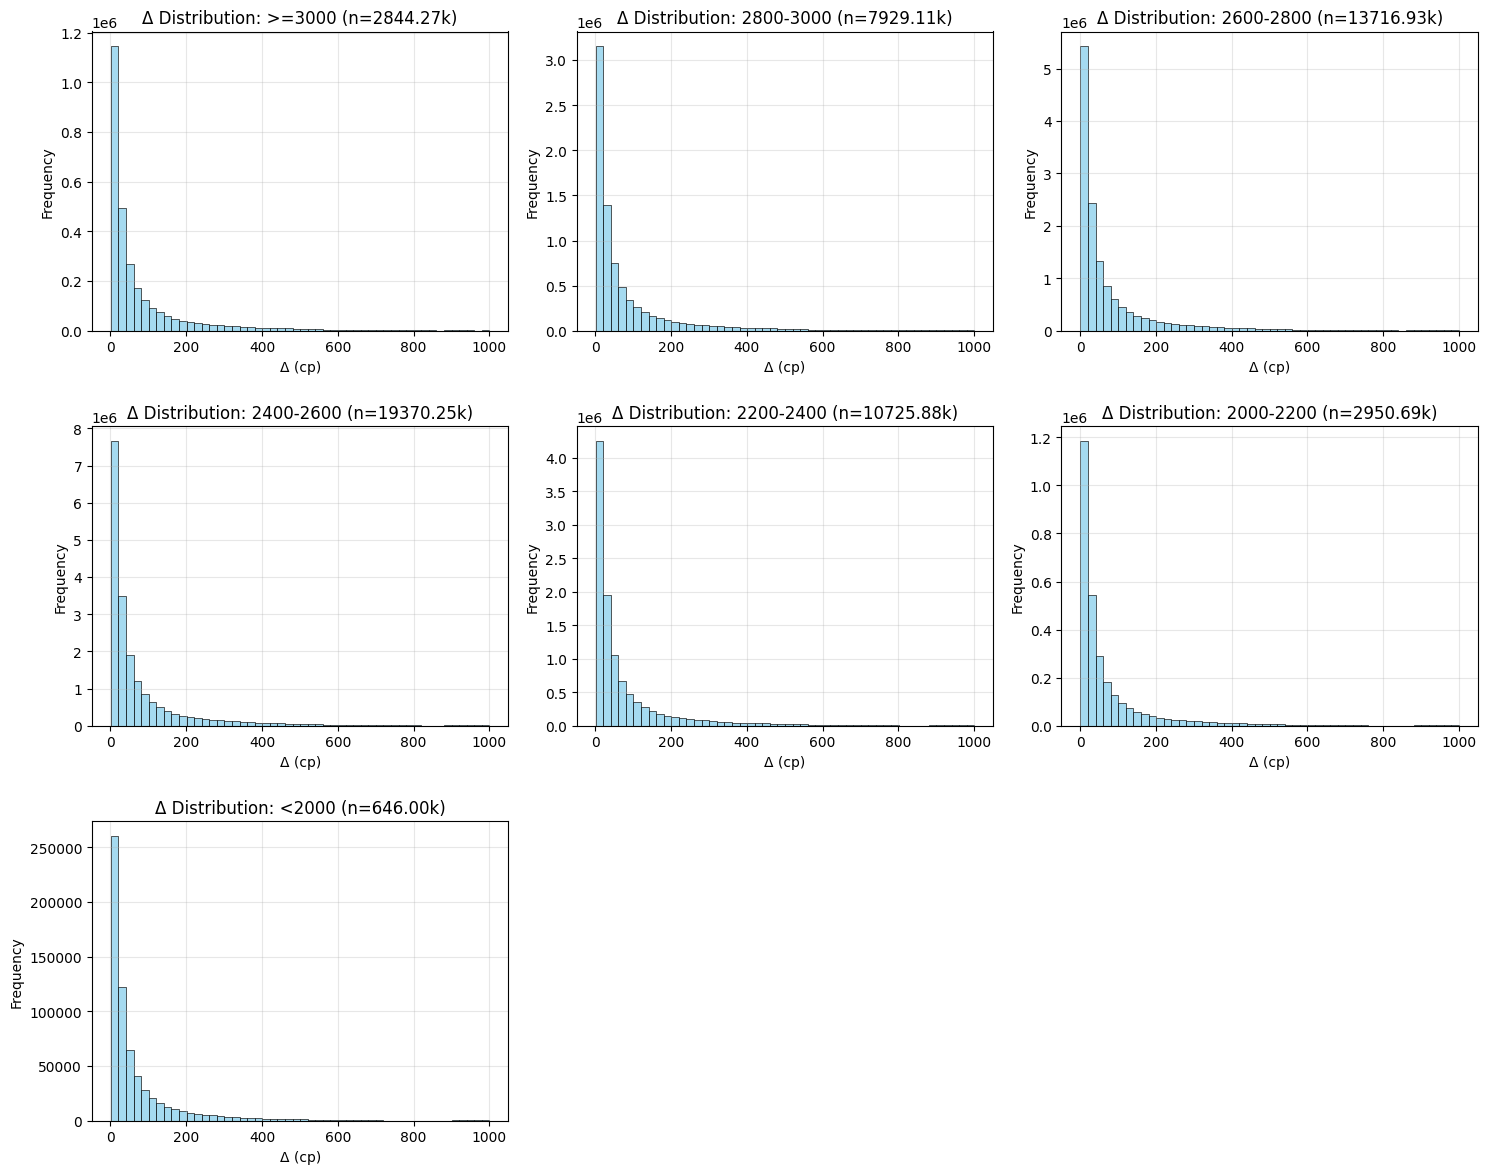

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_delta_distribution(df, group_order, x_limit=1000):
    # 创建一个多子图画板，3行3列足够放7个组
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten() # 展平方便循环
    
    for i, g in enumerate(group_order):
        # 1. 筛选该组的有效非强制步
        sub_df = df[(df['ELO_Group'] == g) & (df['Is_Forced'] == 0) & (df['Δ'] > 0)]
        
        # 2. 截取主体部分查看分布
        data_to_plot = sub_df['Δ'][sub_df['Δ'] <= x_limit]
        
        # 3. 画直方图
        ax = axes[i]
        sns.histplot(data_to_plot, bins=50, color='skyblue', ax=ax, kde=False)
        ax.set_title(f'Δ Distribution: {g} (n={len(data_to_plot)/1000:.2f}k)')
        ax.set_xlabel('Δ (cp)')
        ax.set_ylabel('Frequency')
        ax.grid(alpha=0.3)
        
    # 隐藏多余的空白子图
    for j in range(len(group_order), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# 运行查看分布
plot_delta_distribution(df_moves, group_order)


===== ELO group: >=3000 =====
最优天花板 A   = 0.877
最优阈值 τ     = 162.2
理论验证 73%*A = 0.641

===== ELO group: 2800-3000 =====
最优天花板 A   = 0.872
最优阈值 τ     = 179.1
理论验证 73%*A = 0.637

===== ELO group: 2600-2800 =====
最优天花板 A   = 0.868
最优阈值 τ     = 195.5
理论验证 73%*A = 0.634

===== ELO group: 2400-2600 =====
最优天花板 A   = 0.853
最优阈值 τ     = 202.5
理论验证 73%*A = 0.624

===== ELO group: 2200-2400 =====
最优天花板 A   = 0.841
最优阈值 τ     = 210.1
理论验证 73%*A = 0.615

===== ELO group: 2000-2200 =====
最优天花板 A   = 0.817
最优阈值 τ     = 205.6
理论验证 73%*A = 0.597

===== ELO group: <2000 =====
最优天花板 A   = 0.720
最优阈值 τ     = 158.3
理论验证 73%*A = 0.526


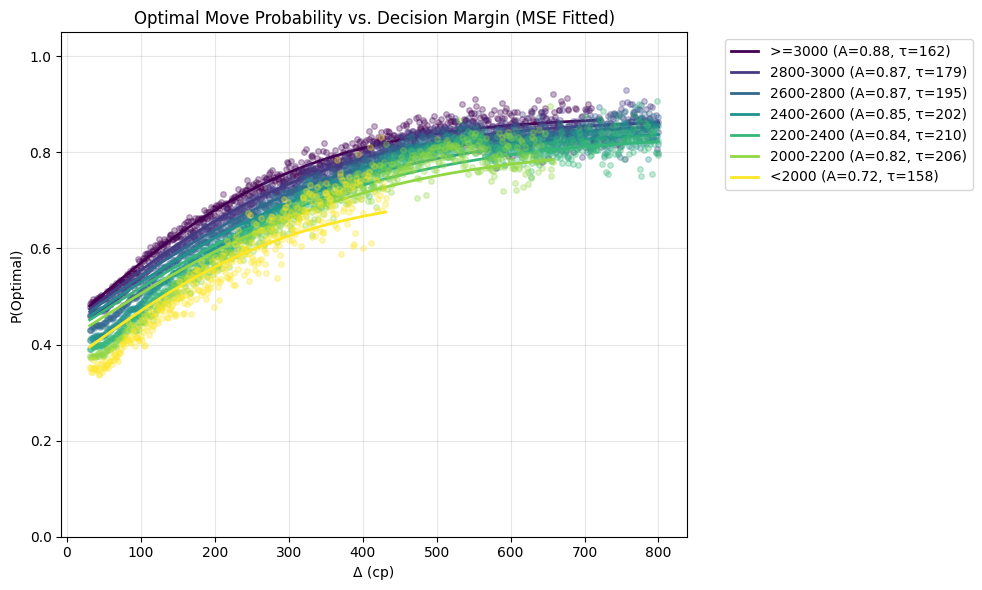

In [ ]:
# 新的方法拟合
from scipy.optimize import curve_fit
def theoretical_logistic(delta, A, tau):
    exponent = np.clip(-delta/tau, -700, 700)
    return A/(1+ np.exp(exponent))

def empirical_curve(df, group_name, delta_min = 30, delta_max = 800, min_count = 100):
    group_df = df[(df['ELO_Group'] == group_name) & (df['Is_Forced'] == 0)]
    group_df = group_df[(group_df['Δ'] > delta_min) & (group_df['Δ'] <= delta_max)]
    if group_df.empty: return None

    counts = group_df.groupby('Δ')['Is_Optimal'].count()
    valid_deltas = counts[counts >= min_count].index
    group_df = group_df[group_df['Δ'].isin(valid_deltas)]

    if group_df.empty: return None
    prob_df=(group_df.groupby('Δ')['Is_Optimal'].mean().reset_index().rename(columns = {'Is_Optimal': 'P_Optimal'}).sort_values('Δ').reset_index(drop=True))
    return prob_df

def fit_mse(prob_df):
    if prob_df is None or prob_df.empty:
        return None, None
    x_data = prob_df['Δ'].values
    y_data = prob_df['P_Optimal'].values
    initial_guess = [y_data.max(), 100.0]
    bounds = ([0.0, 1.0], [1.0, 2000.0])
    try:
        popt, _ = curve_fit(
            theoretical_logistic, 
            x_data, y_data, 
            p0=initial_guess, 
            bounds=bounds
        )
        return popt[0], popt[1]  # 返回最优的 A 和 tau
    except Exception as e:
        print(f"拟合失败: {e}")
        return None, None
group_order = ['>=3000', '2800-3000', '2600-2800',
            '2400-2600', '2200-2400', '2000-2200', '<2000']

all_prob_curves = {}
results = {}


===== ELO group: >=3000 =====
使用参数 -> delta_max: 800, min_count: 50
最优天花板 A   = 0.874
最优阈值 τ     = 159.4


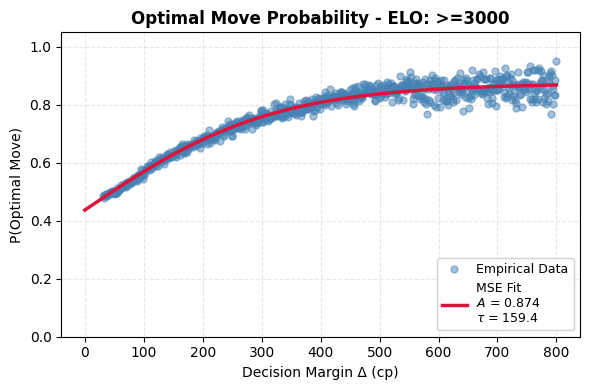


===== ELO group: 2800-3000 =====
使用参数 -> delta_max: 800, min_count: 80
最优天花板 A   = 0.872
最优阈值 τ     = 179.1


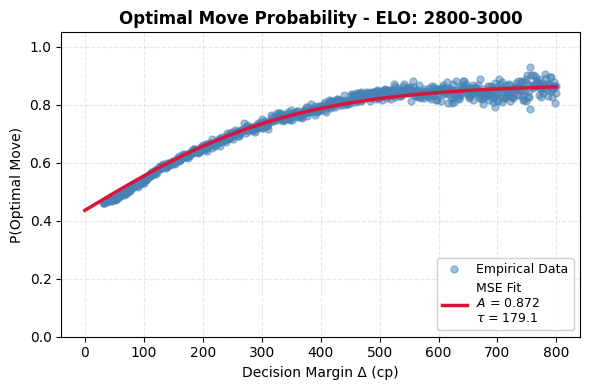


===== ELO group: 2600-2800 =====
使用参数 -> delta_max: 800, min_count: 100
最优天花板 A   = 0.868
最优阈值 τ     = 195.5


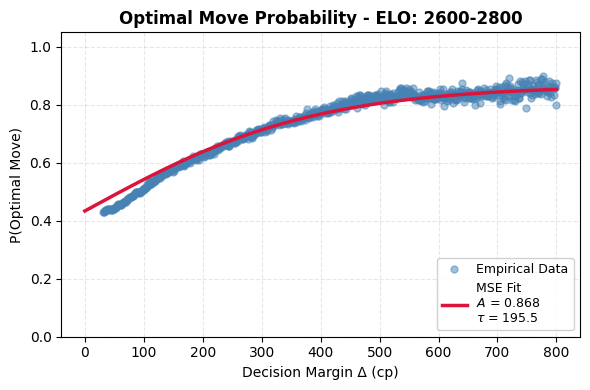


===== ELO group: 2400-2600 =====
使用参数 -> delta_max: 800, min_count: 150
最优天花板 A   = 0.853
最优阈值 τ     = 202.5


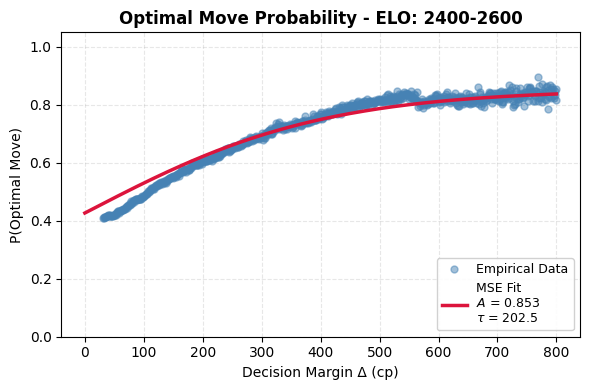


===== ELO group: 2200-2400 =====
使用参数 -> delta_max: 800, min_count: 100
最优天花板 A   = 0.841
最优阈值 τ     = 210.1


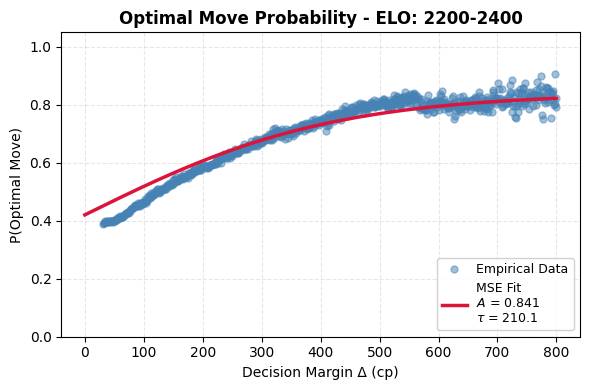


===== ELO group: 2000-2200 =====
使用参数 -> delta_max: 800, min_count: 50
最优天花板 A   = 0.822
最优阈值 τ     = 209.6


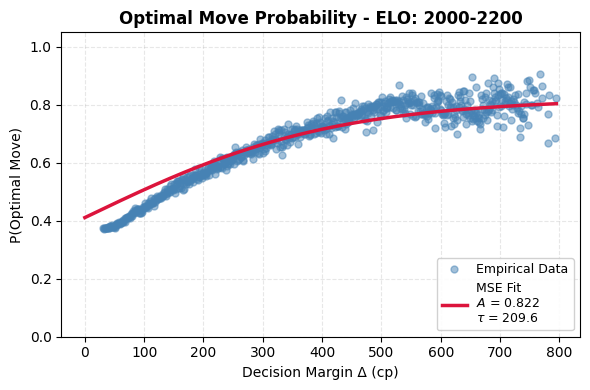


===== ELO group: <2000 =====
使用参数 -> delta_max: 600, min_count: 30
最优天花板 A   = 0.786
最优阈值 τ     = 197.7


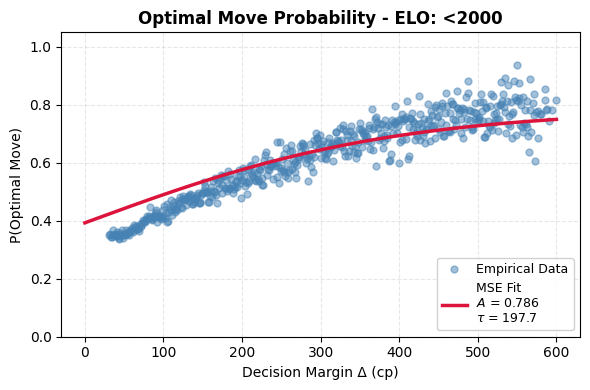

In [38]:
# 定制每个组的参数
group_configs = {
    '>=3000':   {'delta_max': 800,  'min_count': 50},  # 顶尖棋手样本少，阈值放宽点
    '2800-3000':{'delta_max': 800, 'min_count': 80},
    '2600-2800':{'delta_max': 800, 'min_count': 100},
    '2400-2600':{'delta_max': 800, 'min_count': 150}, # 中间段位人多，可以严格点
    '2200-2400':{'delta_max': 800, 'min_count': 100},
    '2000-2200':{'delta_max': 800, 'min_count': 50},
    '<2000':    {'delta_max': 600, 'min_count': 30}  # 低分段样本可能也少
}

all_prob_curves = {}
results = {}

for g in group_order:
    print(f'\n===== ELO group: {g} =====')

    # 从你的配置字典里读取专属参数
    cfg = group_configs.get(g, {'delta_max': 1000, 'min_count': 100})
    d_max = cfg['delta_max']
    m_cnt = cfg['min_count']
    
    print(f'使用参数 -> delta_max: {d_max}, min_count: {m_cnt}')

    # 获取聚合后的经验散点数据
    prob_df = empirical_curve(df_moves[df_moves['Is_Forced'] == 0], group_name=g, delta_min=30, delta_max=d_max, min_count=m_cnt)

    if prob_df is None:
        print('No valid data.')
        continue

    # 执行严谨的 MSE 拟合
    A, tau = fit_mse(prob_df)
    
    if A is None:
        continue

    print(f'最优天花板 A   = {A:.3f}')
    print(f'最优阈值 τ     = {tau:.1f}')

    all_prob_curves[g] = prob_df
    results[g] = {'A': A, 'tau': tau}
    
    # ==========================================
    # 画图：散点和曲线异色显示
    # ==========================================
    plt.figure(figsize=(6, 4))
    
    x_data = prob_df['Δ'].values
    y_data = prob_df['P_Optimal'].values
    
    # 1. 散点：使用半透明的钢蓝色 (steelblue)
    plt.plot(x_data, y_data, 'o', color='steelblue', alpha=0.5, markersize=5, label='Empirical Data')
    
    # 2. 曲线：使用鲜艳的深红色 (crimson)
    x_smooth = np.linspace(0, x_data.max(), 200) 
    y_smooth = theoretical_logistic(x_smooth, A, tau)
    
    fit_label = f'MSE Fit\n$A$ = {A:.3f}\n$\\tau$ = {tau:.1f}'
    plt.plot(x_smooth, y_smooth, '-', color='crimson', lw=2.5, label=fit_label)

    # 排版美化
    plt.title(f'Optimal Move Probability - ELO: {g}', fontsize=12, fontweight='bold')
    plt.xlabel('Decision Margin Δ (cp)', fontsize=10)
    plt.ylabel('P(Optimal Move)', fontsize=10)
    plt.ylim(0, 1.05)
    
    plt.legend(loc='lower right', fontsize=9, framealpha=0.9)
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

In [22]:
clock_info = pd.read_csv(r'..\..\data\input\clock_info.csv')
print(clock_info['white_sec'].apply(type).value_counts())
print(clock_info['black_sec'].apply(type).value_counts())

white_sec
<class 'str'>    1017708
Name: count, dtype: int64
black_sec
<class 'str'>    1017708
Name: count, dtype: int64


In [23]:
clock_info.head()

,uid,seconds,second_list,white_sec,black_sec,white_durations,black_durations
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 179.1, 179.4, 178.6, 178.7, 178.0, 177...","[178.3, 178.0, 177.2, 176.5, 176.5, 176.1, 174...","[1.0, -0.3, 0.8, -0.1, 0.7, 0.7, 0.0, 0.9, 1.1...","[0.3, 0.8, 0.7, 0.0, 0.4, 1.9, 0.0, -0.2, 0.8,..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 178.5, 178.3, 177.7, 177.6, 177.9, 177...","[179.1, 178.5, 178.2, 178.0, 176.6, 175.9, 173...","[0.9, 0.2, 0.6, 0.1, -0.3, 0.8, 0.3, 3.4, 3.2,...","[0.6, 0.3, 0.2, 1.4, 0.7, 2.7, 8.5, -0.2, 12.6..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 180.4, 180.5, 178.1, 179.0, 175.2, 174...","[178.3, 177.0, 177.1, 177.1, 173.1, 172.0, 171...","[-0.5, -0.1, 2.4, -0.9, 3.8, 0.3, -0.2, 2.8, 1...","[1.3, -0.1, 0.0, 4.0, 1.1, 0.1, -0.5, 0.3, 1.0..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.2, 173.9, 173.9, 167.6, 166.7, 161...","[179.3, 174.2, 174.0, 173.9, 171.7, 171.4, 170...","[0.2, 5.3, 0.0, 6.3, 0.9, 5.3, -0.1, 14.8, 9.4...","[5.1, 0.2, 0.1, 2.2, 0.3, 0.9, 1.5, 4.3, 4.5, ..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 180.9, 181.0, 180.2, 179.9, 180.8, 181...","[177.1, 173.7, 172.2, 170.7, 170.0, 170.1, 165...","[0.0, -0.1, 0.8, 0.3, -0.9, -0.5, 3.4, 0.6, 0....","[3.4, 1.5, 1.5, 0.7, -0.1, 5.1, 4.6, 5.5, 3.6,..."


In [24]:
def ensure_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, (int, float)):
        return [x]
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            if isinstance(v, list):
                return v
            elif isinstance(v, (int, float)):
                return [v]
            else:
                return []
        except:
            return []
    try:
        return list(x)
    except:
        return []

clock_info['white_sec'] = clock_info['white_sec'].progress_apply(ensure_list)
clock_info['black_sec'] = clock_info['black_sec'].progress_apply(ensure_list)
print(clock_info['white_sec'].apply(type).value_counts())
print(clock_info['black_sec'].apply(type).value_counts())
clock_info['second_list'] = clock_info['second_list'].progress_apply(ensure_list)
print(clock_info['second_list'].apply(type).value_counts())

  0%|          | 0/1017708 [00:00<?, ?it/s]

  0%|          | 0/1017708 [00:00<?, ?it/s]

white_sec
<class 'list'>    1017708
Name: count, dtype: int64
black_sec
<class 'list'>    1017708
Name: count, dtype: int64


  0%|          | 0/1017708 [00:00<?, ?it/s]

second_list
<class 'list'>    1017708
Name: count, dtype: int64


In [25]:
clock_info.head()

,uid,seconds,second_list,white_sec,black_sec,white_durations,black_durations
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 179.1, 179.4, 178.6, 178.7, 178.0, 177...","[178.3, 178.0, 177.2, 176.5, 176.5, 176.1, 174...","[1.0, -0.3, 0.8, -0.1, 0.7, 0.7, 0.0, 0.9, 1.1...","[0.3, 0.8, 0.7, 0.0, 0.4, 1.9, 0.0, -0.2, 0.8,..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 178.5, 178.3, 177.7, 177.6, 177.9, 177...","[179.1, 178.5, 178.2, 178.0, 176.6, 175.9, 173...","[0.9, 0.2, 0.6, 0.1, -0.3, 0.8, 0.3, 3.4, 3.2,...","[0.6, 0.3, 0.2, 1.4, 0.7, 2.7, 8.5, -0.2, 12.6..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 180.4, 180.5, 178.1, 179.0, 175.2, 174...","[178.3, 177.0, 177.1, 177.1, 173.1, 172.0, 171...","[-0.5, -0.1, 2.4, -0.9, 3.8, 0.3, -0.2, 2.8, 1...","[1.3, -0.1, 0.0, 4.0, 1.1, 0.1, -0.5, 0.3, 1.0..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.2, 173.9, 173.9, 167.6, 166.7, 161...","[179.3, 174.2, 174.0, 173.9, 171.7, 171.4, 170...","[0.2, 5.3, 0.0, 6.3, 0.9, 5.3, -0.1, 14.8, 9.4...","[5.1, 0.2, 0.1, 2.2, 0.3, 0.9, 1.5, 4.3, 4.5, ..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 180.9, 181.0, 180.2, 179.9, 180.8, 181...","[177.1, 173.7, 172.2, 170.7, 170.0, 170.1, 165...","[0.0, -0.1, 0.8, 0.3, -0.9, -0.5, 3.4, 0.6, 0....","[3.4, 1.5, 1.5, 0.7, -0.1, 5.1, 4.6, 5.5, 3.6,..."


In [26]:
# clock_info合并至df_moves
clock_dict = dict(zip(clock_info['uid'], clock_info['second_list']))
def get_remaining_time(row):
    uid = row['uid']
    move_idx = row['Move_Idx']-1   # Move_Idx比对应的列表里元素index大1
    if uid in clock_dict:
        time_list = clock_dict[uid]
        if move_idx < len(time_list):
            return time_list[move_idx]
    return None
df_moves['Remain_Time'] = df_moves.progress_apply(get_remaining_time, axis=1)

  0%|          | 0/9086334 [00:00<?, ?it/s]

In [27]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0,2802,2800-3000,0,1,179.8
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,3.0,4.0,2463,2400-2600,0,1,177.8
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,6.0,8.0,2802,2800-3000,0,1,178.5
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,39.0,2463,2400-2600,0,0,178.7
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,16.0,2802,2800-3000,0,0,179.2


In [28]:
# 根据剩余时间去分组
def time_group(second):
    if second <= 15:
        return 'Extremely Tense (0-15)'
    elif 15< second <= 70:
        return 'Tense (15-70)'
    elif 70< second <=170:
        return 'Middle (70-170)'
    else:
        return 'Rich (>170)'

df_moves['Time_Group'] = df_moves['Remain_Time'].apply(time_group)
df_moves['Time_Group'].value_counts(normalize=True)

Time_Group
Middle (70-170)           0.378831
Tense (15-70)             0.243047
Extremely Tense (0-15)    0.190858
Rich (>170)               0.187265
Name: proportion, dtype: float64

In [29]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,...,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,...,0,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170)
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,...,0,0,3.0,4.0,2463,2400-2600,0,1,177.8,Rich (>170)
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,...,0,0,6.0,8.0,2802,2800-3000,0,1,178.5,Rich (>170)
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,...,0,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170)
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,...,0,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170)


# Re-darw by time group

正在处理: Time=Rich (>170), ELO=2800-3000, Samples=230345
正在处理: Time=Rich (>170), ELO=2400-2600, Samples=566796
正在处理: Time=Rich (>170), ELO=>=3000, Samples=92816
正在处理: Time=Rich (>170), ELO=2600-2800, Samples=406519
正在处理: Time=Rich (>170), ELO=2200-2400, Samples=307387
正在处理: Time=Rich (>170), ELO=2000-2200, Samples=79594
正在处理: Time=Rich (>170), ELO=<2000, Samples=18097
正在处理: Time=Middle (70-170), ELO=2800-3000, Samples=449446
正在处理: Time=Middle (70-170), ELO=2400-2600, Samples=1154125
正在处理: Time=Middle (70-170), ELO=>=3000, Samples=177900
正在处理: Time=Middle (70-170), ELO=2600-2800, Samples=804770
正在处理: Time=Middle (70-170), ELO=2200-2400, Samples=638945
正在处理: Time=Middle (70-170), ELO=2000-2200, Samples=174087
正在处理: Time=Middle (70-170), ELO=<2000, Samples=42909
正在处理: Time=Tense (15-70), ELO=2800-3000, Samples=288855
正在处理: Time=Tense (15-70), ELO=2400-2600, Samples=742646
正在处理: Time=Tense (15-70), ELO=>=3000, Samples=104601
正在处理: Time=Tense (15-70), ELO=2600-2800, Samples=519019
正在处理: Time=T

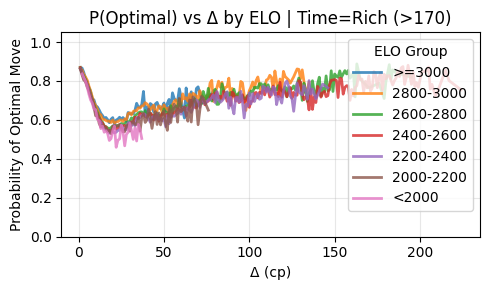

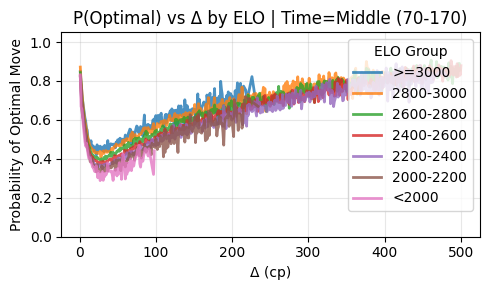

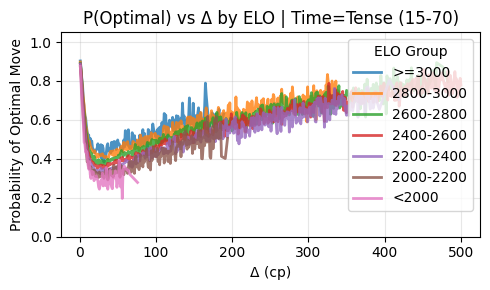

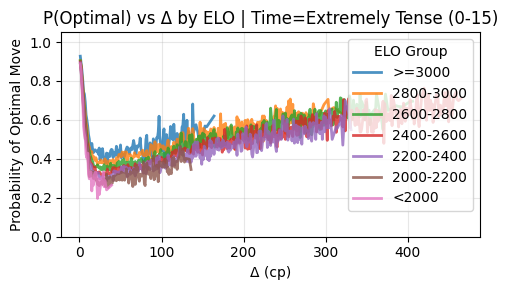

In [30]:
def empirical_curve_v2(df, label, delta_max=1000, show_plot=True):
    # 只过滤非强制着法 和 过滤 Δ 范围
    group_df = df[df['Is_Forced'] == 0].copy()
    group_df = group_df[(group_df['Δ'] > 0) & (group_df['Δ'] <= delta_max)]
    
    if group_df.empty:
        print(f"Warning: No data for {label}")
        return pd.DataFrame(columns=['Δ', 'P_Optimal'])

    counts = group_df.groupby('Δ', observed=True)['Is_Optimal'].count()
    valid_deltas = counts[counts >= 100].index   #50可以调
    group_df = group_df[group_df['Δ'].isin(valid_deltas)]

    if group_df.empty:
        return pd.DataFrame(columns=['Δ', 'P_Optimal'])

    # 统计概率，prob_df包含每个Δ和对应的最优步概率
    prob_df = group_df.groupby('Δ', observed=True)['Is_Optimal'].mean().reset_index()
    prob_df.rename(columns={'Is_Optimal': 'P_Optimal'}, inplace=True)
    
    return prob_df

# 按照时间紧张程度看不同elo组的表现情况
all_prob_curves_time = {}
time_groups = df_moves['Time_Group'].unique()
elo_groups = df_moves['ELO_Group'].unique()

for t_group in time_groups:
    all_prob_curves_time[t_group] = {}
    for e_group in elo_groups:
        # 在此处进行精确过滤
        sub_df = df_moves[(df_moves['Time_Group'] == t_group) & (df_moves['ELO_Group'] == e_group)]
        
        print(f"正在处理: Time={t_group}, ELO={e_group}, Samples={len(sub_df)}")
        
        prob_curve = empirical_curve_v2(
            df = sub_df,
            label = f'{e_group} | {t_group}',
            delta_max = 500,
            show_plot = False # 循环中关闭单图，最后一起画总图
        )
        all_prob_curves_time[t_group][e_group] = prob_curve
# 具体画图
for t_group in time_groups:
    plt.figure(figsize=(5,3))
    elo_order=['>=3000', '2800-3000', '2600-2800',
               '2400-2600', '2200-2400', '2000-2200', '<2000']
    colors = plt.cm.tab10.colors

    for i, e_group in enumerate(elo_order):
        if e_group not in all_prob_curves_time[t_group]:
            continue

        curve = all_prob_curves_time[t_group][e_group]
        if curve is None or curve.empty:
            continue

        plt.plot(
            curve['Δ'],
            curve['P_Optimal'],
            lw=2,
            color=colors[i % len(colors)],
            alpha=0.8,
            label=e_group
        )

    plt.xlabel('Δ (cp)')
    plt.ylabel('Probability of Optimal Move')
    plt.title(f'P(Optimal) vs Δ by ELO | Time={t_group}')
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend(title='ELO Group')
    plt.tight_layout()
    plt.show()


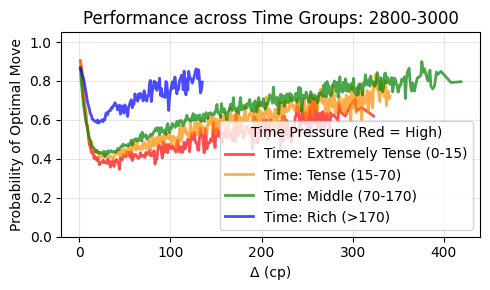

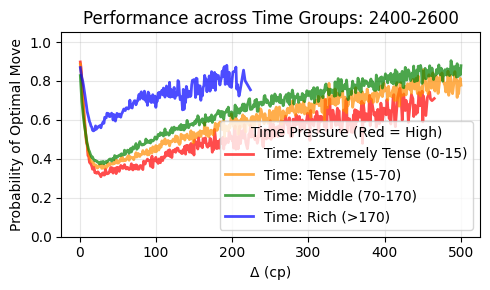

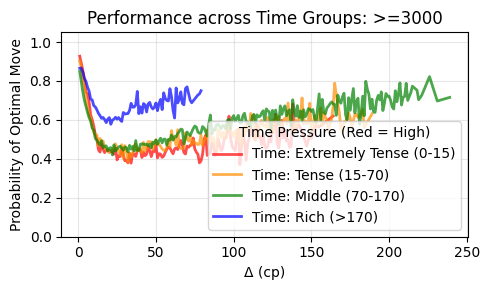

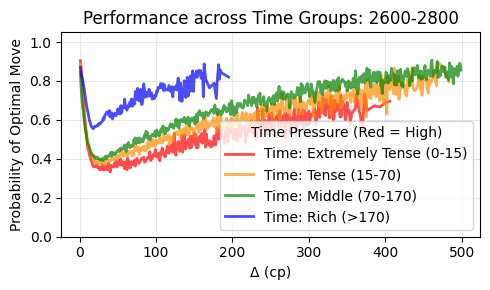

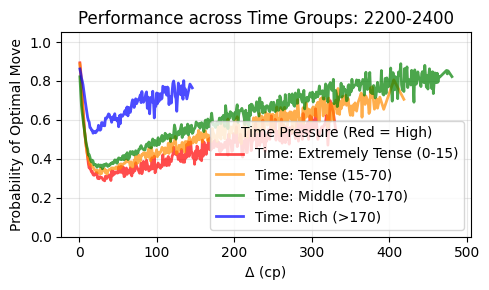

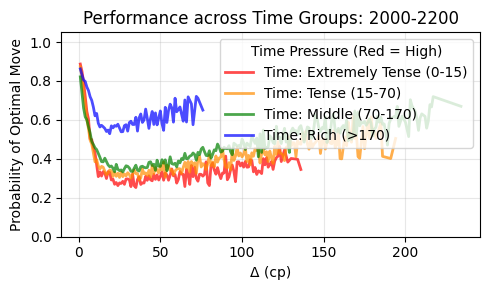

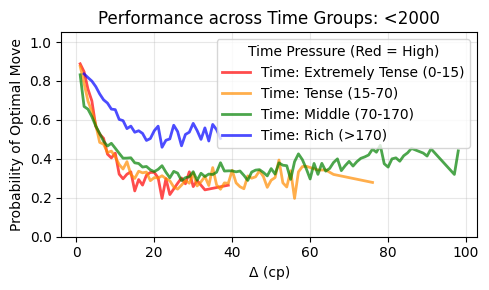

In [31]:
time_color_map = {
    'Extremely Tense (0-15)': 'red',
    'Tense (15-70)': 'darkorange',
    'Middle (70-170)': 'green',
    'Rich (>170)': 'blue'
}

legend_order = [
    'Extremely Tense (0-15)',
    'Tense (15-70)',
    'Middle (70-170)',
    'Rich (>170)'
]

for e_group in elo_groups:
    plt.figure(figsize=(5, 3))

    for t_group in legend_order:
        curve = all_prob_curves_time[t_group].get(e_group)
        if curve is None or curve.empty:
            continue

        plt.plot(
            curve['Δ'],
            curve['P_Optimal'],
            lw=2,
            alpha=0.7,
            color=time_color_map[t_group],
            label=f'Time: {t_group}'
        )

    plt.xlabel('Δ (cp)')
    plt.ylabel('Probability of Optimal Move')
    plt.title(f'Performance across Time Groups: {e_group}')
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)

    # —— 手动控制 legend 顺序 ——
    handles, labels = plt.gca().get_legend_handles_labels()
    label_to_handle = dict(zip(labels, handles))

    ordered_handles = []
    ordered_labels = []

    for t in legend_order:
        label = f'Time: {t}'
        if label in label_to_handle:
            ordered_handles.append(label_to_handle[label])
            ordered_labels.append(label)

    plt.legend(
        ordered_handles,
        ordered_labels,
        title="Time Pressure (Red = High)"
    )

    plt.tight_layout()
    plt.show()


# Time-Weighted

In [32]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,...,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,...,0,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170)
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,...,0,0,3.0,4.0,2463,2400-2600,0,1,177.8,Rich (>170)
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,...,0,0,6.0,8.0,2802,2800-3000,0,1,178.5,Rich (>170)
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,...,0,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170)
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,...,0,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170)


In [33]:
clock_info.head()

,uid,seconds,second_list,white_sec,black_sec,white_durations,black_durations
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 179.1, 179.4, 178.6, 178.7, 178.0, 177...","[178.3, 178.0, 177.2, 176.5, 176.5, 176.1, 174...","[1.0, -0.3, 0.8, -0.1, 0.7, 0.7, 0.0, 0.9, 1.1...","[0.3, 0.8, 0.7, 0.0, 0.4, 1.9, 0.0, -0.2, 0.8,..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 178.5, 178.3, 177.7, 177.6, 177.9, 177...","[179.1, 178.5, 178.2, 178.0, 176.6, 175.9, 173...","[0.9, 0.2, 0.6, 0.1, -0.3, 0.8, 0.3, 3.4, 3.2,...","[0.6, 0.3, 0.2, 1.4, 0.7, 2.7, 8.5, -0.2, 12.6..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 180.4, 180.5, 178.1, 179.0, 175.2, 174...","[178.3, 177.0, 177.1, 177.1, 173.1, 172.0, 171...","[-0.5, -0.1, 2.4, -0.9, 3.8, 0.3, -0.2, 2.8, 1...","[1.3, -0.1, 0.0, 4.0, 1.1, 0.1, -0.5, 0.3, 1.0..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.2, 173.9, 173.9, 167.6, 166.7, 161...","[179.3, 174.2, 174.0, 173.9, 171.7, 171.4, 170...","[0.2, 5.3, 0.0, 6.3, 0.9, 5.3, -0.1, 14.8, 9.4...","[5.1, 0.2, 0.1, 2.2, 0.3, 0.9, 1.5, 4.3, 4.5, ..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 180.9, 181.0, 180.2, 179.9, 180.8, 181...","[177.1, 173.7, 172.2, 170.7, 170.0, 170.1, 165...","[0.0, -0.1, 0.8, 0.3, -0.9, -0.5, 3.4, 0.6, 0....","[3.4, 1.5, 1.5, 0.7, -0.1, 5.1, 4.6, 5.5, 3.6,..."


In [34]:
def safe_literal_eval(val):
    if isinstance(val, str):
        return ast.literal_eval(val)
    return val

clock_info['white_durations'] = clock_info['white_durations'].progress_apply(safe_literal_eval)
clock_info['black_durations'] = clock_info['black_durations'].progress_apply(safe_literal_eval)

  0%|          | 0/1017708 [00:00<?, ?it/s]

  0%|          | 0/1017708 [00:00<?, ?it/s]

In [35]:
time_lookup = clock_info.set_index('uid')[['white_durations', 'black_durations']].to_dict('index')
def get_move_duration(row):
    uid = row['uid']
    move_idx = row['Move_Idx']
    color = row['Color']
    
    # 1. 检查该局游戏是否存在于时间表中
    if uid not in time_lookup:
        return None
    
    # 2. 根据颜色选择对应的时间列表
    game_times = time_lookup[uid]
    if color == 'White':
        durations = game_times['white_durations']
    elif color == 'Black':
        durations = game_times['black_durations']
    else:
        return None
        
    # 3. 计算列表索引 (关键数学逻辑)
    # Move_Idx: 1, 2, 3, 4 ...
    # Index:    0, 0, 1, 1 ...
    list_index = (move_idx - 1) // 2
    
    # 4. 安全提取 (防止索引越界)
    if durations and 0 <= list_index < len(durations):
        return durations[list_index]
    else:
        return None

# 4. 应用到 df_moves
print("正在匹配时间数据...")
df_moves['Move_Time'] = df_moves.progress_apply(get_move_duration, axis=1)

# 5. 检查结果
print(df_moves[['uid', 'Move_Idx', 'Color', 'Move_Time']].head(10))

正在匹配时间数据...


  0%|          | 0/9086334 [00:00<?, ?it/s]

   uid  Move_Idx  Color  Move_Time
0   34         1  White        1.3
1   34         2  Black       -0.9
2   34         3  White       -0.7
3   34         4  Black        0.4
4   34         5  White        0.1
5   34         6  Black        0.0
6   34         7  White       -0.5
7   34         8  Black       -0.2
8   34         9  White        0.2
9   34        10  Black       -0.5


In [36]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,...,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,...,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170),1.3
1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,...,0,3.0,4.0,2463,2400-2600,0,1,177.8,Rich (>170),-0.9
2,34,3,Dennis Wagner,White,30,36,33,27,25,20,...,0,6.0,8.0,2802,2800-3000,0,1,178.5,Rich (>170),-0.7
3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,...,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170),0.4
4,34,5,Dennis Wagner,White,32,44,35,26,21,21,...,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170),0.1


In [37]:
time_complex = (df_moves .copy()
    .loc[df_moves['Move_Time'].notna() & (df_moves['Move_Time'] >= 0)]
    .reset_index(drop=True)
)
print(time_complex.shape)
print(df_moves.shape)
time_complex.head()

(6686325, 22)
(9086334, 22)


,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,...,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time
0,34,1,Dennis Wagner,White,33,36,34,31,25,16,...,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170),1.3
1,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,...,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170),0.4
2,34,5,Dennis Wagner,White,32,44,35,26,21,21,...,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170),0.1
3,34,6,Petar Ratkovic,Black,39,32,37,67,71,72,...,0,7.0,24.0,2463,2400-2600,0,1,178.3,Rich (>170),0.0
4,34,9,Dennis Wagner,White,32,39,23,17,12,11,...,0,7.0,21.0,2802,2800-3000,0,1,179.6,Rich (>170),0.2


In [38]:
df_moves.to_csv('0211.csv')

# 运行到这里停一下，新开一个notebook

| ELO 组     | A（能力上限） | 0.73·A | 反解得到的 Δ₀ (cp) |
| --------- | ------- | ------ | ------------- |
| ≥ 3000    | 0.772   | 0.563  | **105.3**     |
| 2800–3000 | 0.749   | 0.547  | **113.3**     |
| 2600–2800 | 0.733   | 0.535  | **118.5**     |
| 2400–2600 | 0.712   | 0.519  | **122.5**     |
| 2200–2400 | 0.691   | 0.505  | **138.3**     |
| 2000–2200 | 0.679   | 0.496  | **129.8**     |
| < 2000    | 0.656   | 0.479  | **can't estimate by now**    |


In [40]:
GLOBAL_DELTA_0 = 10.0  #论文的值10cp画出来的图分布太不平衡了，改成我自己求出来的中间的数字100cp

# 1. 计算 P (向量化)
# 使用 np.exp 可以直接处理整个数组
# 这里的 clip 是为了防止溢出
delta_values = time_complex['Δ'].values
p_values = 1 / (1 + np.exp(-delta_values / GLOBAL_DELTA_0))

# 赋值 P
time_complex['P_optimal(Global)'] = p_values

# 2. 计算 S (向量化)
# 处理 P=0 的情况，防止 log 报错
# 使用 np.where: 如果 p > 1e-9 就算 log，否则设为 1.0
time_complex['S(Global)'] = np.where(
    p_values > 1e-9, 
    -np.log2(p_values), 
    1.0
)

# 3. 计算 S/t (向量化)
# 处理时间为 0 的情况
safe_time = time_complex['Move_Time'].replace(0, 0.1) # 把0秒替换成0.1秒
time_complex['Cognitive_Speed(Global)'] = time_complex['S(Global)'] / safe_time

print("计算完成！")

计算完成！


看一下分布，感觉10cp可能会导致全混在一起、

In [ ]:
time_complex['Game_Length'] = (
    time_complex.groupby('uid')['Move_Idx'].transform('max')
)

time_complex['Progress'] = (
    time_complex['Move_Idx'] / time_complex['Game_Length']
)
complex_drop_opening = time_complex[
    (time_complex['Progress'] > 0.20) &   # 去掉前15%
    (time_complex['Is_Forced'] == 0)
].copy()

In [ ]:
plt.figure(figsize=(15, 5))
# P distribution
plt.subplot(1, 3, 1)
sns.histplot(complex_drop_opening['P_optimal(Global)'], bins=30, kde=True)
plt.title('Distribution of P_optimal(Global)')
plt.xlabel('Probability')
# S distribution
plt.subplot(1, 3, 2)
sns.histplot(complex_drop_opening['S(Global)'], bins=30, kde=True, color='orange')
plt.title('Distribution of Difficulty (Bits)')
plt.xlabel('Entropy S(Global)')
# Cognitive distribution
plt.subplot(1, 3, 3)
# 截断一下长尾，看主体分布
sns.histplot(complex_drop_opening['Cognitive_Speed(Global)'].clip(upper=5), bins=30, kde=True, color='green')
plt.title('Cognitive_Speed(Global) (Bits/sec)')
plt.xlabel('Speed')

plt.tight_layout()
plt.show()

In [ ]:
complex_drop_opening.head()

In [ ]:
# 1. 准备工作：定义分组阈值字典
delta0_map = {
    '>=3000': 105.3,
    '2800-3000': 113.3,
    '2600-2800': 118.5,
    '2400-2600': 122.5,
    '2200-2400': 138.3,
    '2000-2200': 129.8,
    '<2000': 140.0,     # 手动补全
    'Unknown': 120.0    # 默认值
}

# 2. 关键步骤：利用 map 生成一列对齐的 Delta0
# 这行代码会瞬间给几百万行数据填上对应的 Delta0
complex_drop_opening['Delta0_Group'] = complex_drop_opening['ELO_Group'].map(delta0_map)

# 处理一下 map 之后可能产生的 NaN (如果有漏掉的组)，填充为默认值 100
complex_drop_opening['Delta0_Group'] = complex_drop_opening['Delta0_Group'].fillna(100.0)

print("Delta0 分组列生成完毕！预览：")
print(complex_drop_opening[['ELO_Group', 'Delta0_Group']].head())

# --- 开始向量化计算 ---

# 1. 计算 P (Group specific)
# 公式： 1 / (1 + exp(-Δ / Δ0_group))
delta_values = complex_drop_opening['Δ'].values
d0_values = complex_drop_opening['Delta0_Group'].values  # 取出这一列作为分母数组

# 同样使用 numpy 向量运算
p_values_group = 1 / (1 + np.exp(-delta_values / d0_values))

# 赋值 (不带 Global 后缀)
complex_drop_opening['P_optimal'] = p_values_group

# 2. 计算 S (Group specific)
# 同样处理 P接近0 的情况
complex_drop_opening['S'] = np.where(
    p_values_group > 1e-9, 
    -np.log2(p_values_group), 
    1.0
)

# 3. 计算 S/t (Group specific)
# 处理时间为 0 的情况
safe_time = complex_drop_opening['Move_Time'].replace(0, 0.1) 
complex_drop_opening['Cognitive_Speed'] = complex_drop_opening['S'] / safe_time

print("分组指标 (P_optimal, S, Cognitive_Speed) 计算完成！")

In [ ]:
time_complex.head()

In [ ]:
complex_drop_opening.head()

In [ ]:
complex_drop_opening.columns

In [ ]:
# 过滤数据用于画图 (去掉开局和强制步)
plt.figure(figsize=(15, 5))

# 图1: P distribution (Group Specific)
plt.subplot(1, 3, 1)
sns.histplot(complex_drop_opening['P_optimal'], bins=30, kde=True)
plt.title('Distribution of P_optimal (Group Specific)')
plt.xlabel('Probability')

# 图2: S distribution (Group Specific)
plt.subplot(1, 3, 2)
sns.histplot(complex_drop_opening['S'], bins=30, kde=True, color='orange')
plt.title('Distribution of Difficulty S (Bits)')
plt.xlabel('Entropy S')

# 图3: Cognitive Speed distribution (Group Specific)
plt.subplot(1, 3, 3)
sns.histplot(complex_drop_opening['Cognitive_Speed'].clip(upper=5), bins=30, kde=True, color='green')
plt.title('Cognitive_Speed (Bits/sec)')
plt.xlabel('Speed')

plt.tight_layout()
plt.show()

In [ ]:
# 画S（Global和非Global）和P_Optimal的关系
def plot_difficulty_curve(data, x_col, title, ax):
    # 1. 分桶：把 S 切分成 20 个小区间 (0 到 1.0)
    # 使用 pd.cut 把连续的 S 变成区间
    data['S_Bin'] = pd.cut(data[x_col], bins=np.linspace(0, 1.0, 25))
    
    # 2. 聚合：计算每个区间、每个组的 实际准确率 (Is_Optimal)
    agg_data = (
        data.groupby(['ELO_Group', 'S_Bin'])['Is_Optimal']
        .mean()
        .reset_index()
        .rename(columns={'Is_Optimal': 'Actual_Win_Rate'})
    )
    
    # 3. 处理 X 轴：把区间 (0.1, 0.15] 变成中点 0.125 方便画图
    agg_data['S_Mid'] = agg_data['S_Bin'].apply(lambda x: x.mid)
    
    # 4. 画线
    sns.lineplot(
        data=agg_data, 
        x='S_Mid', 
        y='Actual_Win_Rate', 
        hue='ELO_Group', 
        hue_order=elo_order,
        marker='o',
        linewidth=2,
        ax=ax
    )
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Difficulty S (Bits)', fontsize=12)
    ax.set_ylabel('Actual Probability of Optimal Move', fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, 1.0)
    ax.grid(True, alpha=0.3)
    # 添加对角线参考 (理论预测)
    # 理论上 P = 2^(-S)，可以画一条虚线对比实际值
    x_ref = np.linspace(0, 1, 100)
    y_ref = 2 ** (-x_ref)
    ax.plot(x_ref, y_ref, 'k--', alpha=0.5, label='Theoretical Model')


# --- 开始画图 ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 图1：Global Standard (展示能力差距)
plot_difficulty_curve(
    complex_drop_opening.copy(), 
    x_col='S(Global)', 
    title='(A) Global Standard (Δ0=100cp)\nSeparation shows Skill Gap', 
    ax=axes[0]
)

# 图2：Group Specific (展示规律统一)
plot_difficulty_curve(
    complex_drop_opening.copy(), 
    x_col='S', 
    title='(B) Normalized by Skill (Group Δ0)\nCurves Collapse = Universal Law', 
    ax=axes[1]
)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
# 过滤掉极端值以便观察
speed_df = complex_drop_opening[complex_drop_opening['Cognitive_Speed(Global)'] < 5].copy()
sns.boxplot(
    data=speed_df,
    x='ELO_Group',
    y='Cognitive_Speed(Global)',
    order=elo_order,
    palette='viridis',
    showfliers=False  # 不显示离群点，让箱体更清晰
)
plt.title('Cognitive Processing Speed by Skill Level')
plt.ylabel('Bits per Second (Global Standard)')
plt.xlabel('ELO Group')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
# 过滤掉极端值以便观察
speed_df = complex_drop_opening[complex_drop_opening['Cognitive_Speed'] < 5].copy()
sns.boxplot(
    data=speed_df,
    x='ELO_Group',
    y='Cognitive_Speed',
    order=elo_order,
    palette='viridis',
    showfliers=False  # 不显示离群点，让箱体更清晰
)
plt.title('Cognitive Processing Speed by Skill Level')
plt.ylabel('Bits per Second')
plt.xlabel('ELO Group')
plt.grid(axis='y', alpha=0.3)
plt.show() 

In [ ]:
plt.figure(figsize=(10, 6))

# --- 关键修改：只看难题 ---
# 过滤 S(Global) > 0.5 的局面
# 意思是：只看那些真正需要动脑子的棋，这时候谁脑子快一目了然
difficult_moves = complex_drop_opening[
    (complex_drop_opening['S(Global)'] > 0.4) & 
    (complex_drop_opening['S(Global)'] < 0.9) &
    (complex_drop_opening['Cognitive_Speed(Global)'] < 5) &
    (complex_drop_opening['Move_Time'] > 1.0)
].copy()

sns.boxplot(
    data=difficult_moves,
    x='ELO_Group',
    y='Cognitive_Speed(Global)',
    order=elo_order,
    palette='viridis',
    showfliers=False
)

plt.title('Cognitive Speed in Complex Positions (S > 0.5 bits)') # 标题改一下
plt.ylabel('Bits per Second')
plt.xlabel('ELO Group')
plt.show()

棋局复杂度与棋手失误类型的关系

# Complexity 高低 → Blunder / Mistake 发生概率

In [39]:
pd.set_option('display.max_columns', None)
complex_drop_opening.head()

NameError: name 'complex_drop_opening' is not defined

In [ ]:
def plot_hist_with_values(df, col, bins=50, kde=False, title=None, xlabel=None, ylabel='Count', color='blue'):
    """绘制直方图/柱状图并打印每个区间的具体步数。"""
    values = df[col].dropna()
    
    counts, bin_edges = np.histogram(values, bins=bins)
    
    print(f"=== {title if title else col} 每个区间步数 ===")
    for i in range(0, len(counts), 2):
        left = f"{bin_edges[i]:.3f}-{bin_edges[i+1]:.3f}: {counts[i]}"
        if i + 1 < len(counts):
            right = f"{bin_edges[i+1]:.3f}-{bin_edges[i+2]:.3f}: {counts[i+1]}"
            print(f"{left:<30} | {right}")
        else:
            print(left)

    plt.figure(figsize=(8,5))
    sns.histplot(values, bins=bins, kde=kde, color=color)
    plt.title(title if title else col)
    plt.xlabel(xlabel if xlabel else col)
    plt.ylabel(ylabel)
    plt.show()
#mistake blunder distribution
# 只保留错误步
errors_df = complex_drop_opening[complex_drop_opening['Is_Error']==1]

plot_hist_with_values(df=complex_drop_opening, col='S', bins=50, kde=True, title="Mistake / Blunder 's S distribution", xlabel='S', ylabel='Num',color='red')

In [ ]:
def plot_hist_with_values(df, col, bins=50, kde=False, title=None, xlabel=None, ylabel='Count', color='blue'):
    """绘制直方图/柱状图并打印每个区间的具体步数。"""
    values = df[col].dropna()
    
    counts, bin_edges = np.histogram(values, bins=bins)
    
    print(f"=== {title if title else col} 每个区间步数 ===")
    for i in range(0, len(counts), 2):
        left = f"{bin_edges[i]:.3f}-{bin_edges[i+1]:.3f}: {counts[i]}"
        if i + 1 < len(counts):
            right = f"{bin_edges[i+1]:.3f}-{bin_edges[i+2]:.3f}: {counts[i+1]}"
            print(f"{left:<30} | {right}")
        else:
            print(left)

    plt.figure(figsize=(8,5))
    sns.histplot(values, bins=bins, kde=kde, color=color)
    plt.title(title if title else col)
    plt.xlabel(xlabel if xlabel else col)
    plt.ylabel(ylabel)
    plt.show()
#mistake blunder distribution
# 只保留错误步
errors_df = complex_drop_opening[complex_drop_opening['Is_Error']==1]

plot_hist_with_values(df=complex_drop_opening, col='S(Global)', bins=50, kde=True, title="Mistake / Blunder 's S(Global) distribution", xlabel='S(Global)', ylabel='Num',color='red')

In [ ]:
def plot_hist_compare_by_elo(df, elo_order, bins=50, kde=True):
    for elo in elo_order:
        sub_df = df[df['ELO_Group'] == elo]

        values_local = sub_df['S'].dropna()
        values_global = sub_df['S(Global)'].dropna()

        fig, axes = plt.subplots(1, 2, figsize=(10, 3))

        # 左图：Group-specific S
        sns.histplot(values_local, bins=bins, kde=kde, ax=axes[0])
        axes[0].set_title(f"{elo} - S")
        axes[0].set_xlabel("S")
        axes[0].set_ylabel("Count")

        # 右图：Global S
        sns.histplot(values_global, bins=bins, kde=kde, ax=axes[1])
        axes[1].set_title(f"{elo} - S (Global)")
        axes[1].set_xlabel("S")
        axes[1].set_ylabel("Count")

        plt.tight_layout()
        plt.show()

plot_hist_compare_by_elo(
    df=errors_df,
    elo_order=elo_order,
    bins=50,
    kde=True
)
